In [1]:
import numpy as np
import networkx as nx
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from src.graphs.utils import *
from src.hyperbolicity.gromov import *
from src.graphs.visualization import *

from collections import Counter
%load_ext autoreload
%autoreload 2
from src.optimization.solver import *
from src.optimization.objectives import *
import yaml

In [2]:
def get_opt_pm():
    with open("../configs/optimization_parameters.yaml", "r") as file:
        config = yaml.safe_load(file)
    config = config['optimization']
    return config['temperature'],config['alpha_diffusion'],config['time'],config['localized_nodes'],config['lambda_reg']
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()

----------

# new experiments for meeting 13 May

$$ \max_\mu \sum_i \mu_i (\delta(h_i) - d(h_i)) - \mu_i \log(\mu_i)$$  $$ \text{s.t. } \mu_i > 0, \sum_i \mu_i = 1 $$ 

## grid (6,6) 

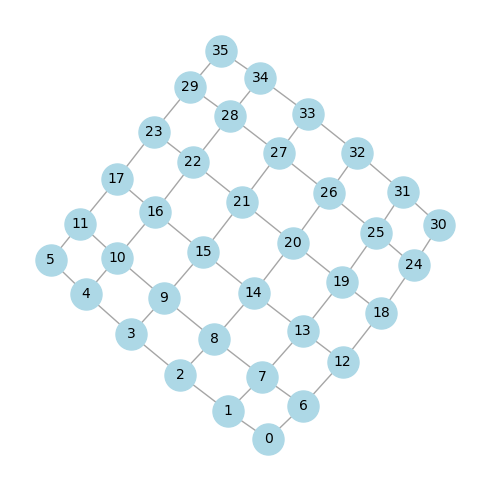

Counter({np.float64(0.0): 34880, np.float64(1.0): 19125, np.float64(2.0): 4224, np.float64(3.0): 627, np.float64(4.0): 48, np.float64(5.0): 1})


In [3]:
G = create_lattice_graph(6,6)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

La cost function e' 0.9999999802129264 - -2.0776427600076413e-08: 1.0000000009893537


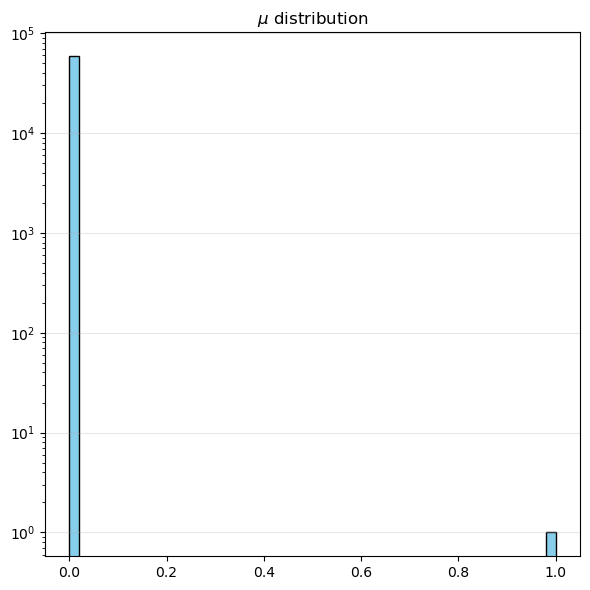

In [4]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()

E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

Too many quadruples to visualize (10), showing only the first 9.


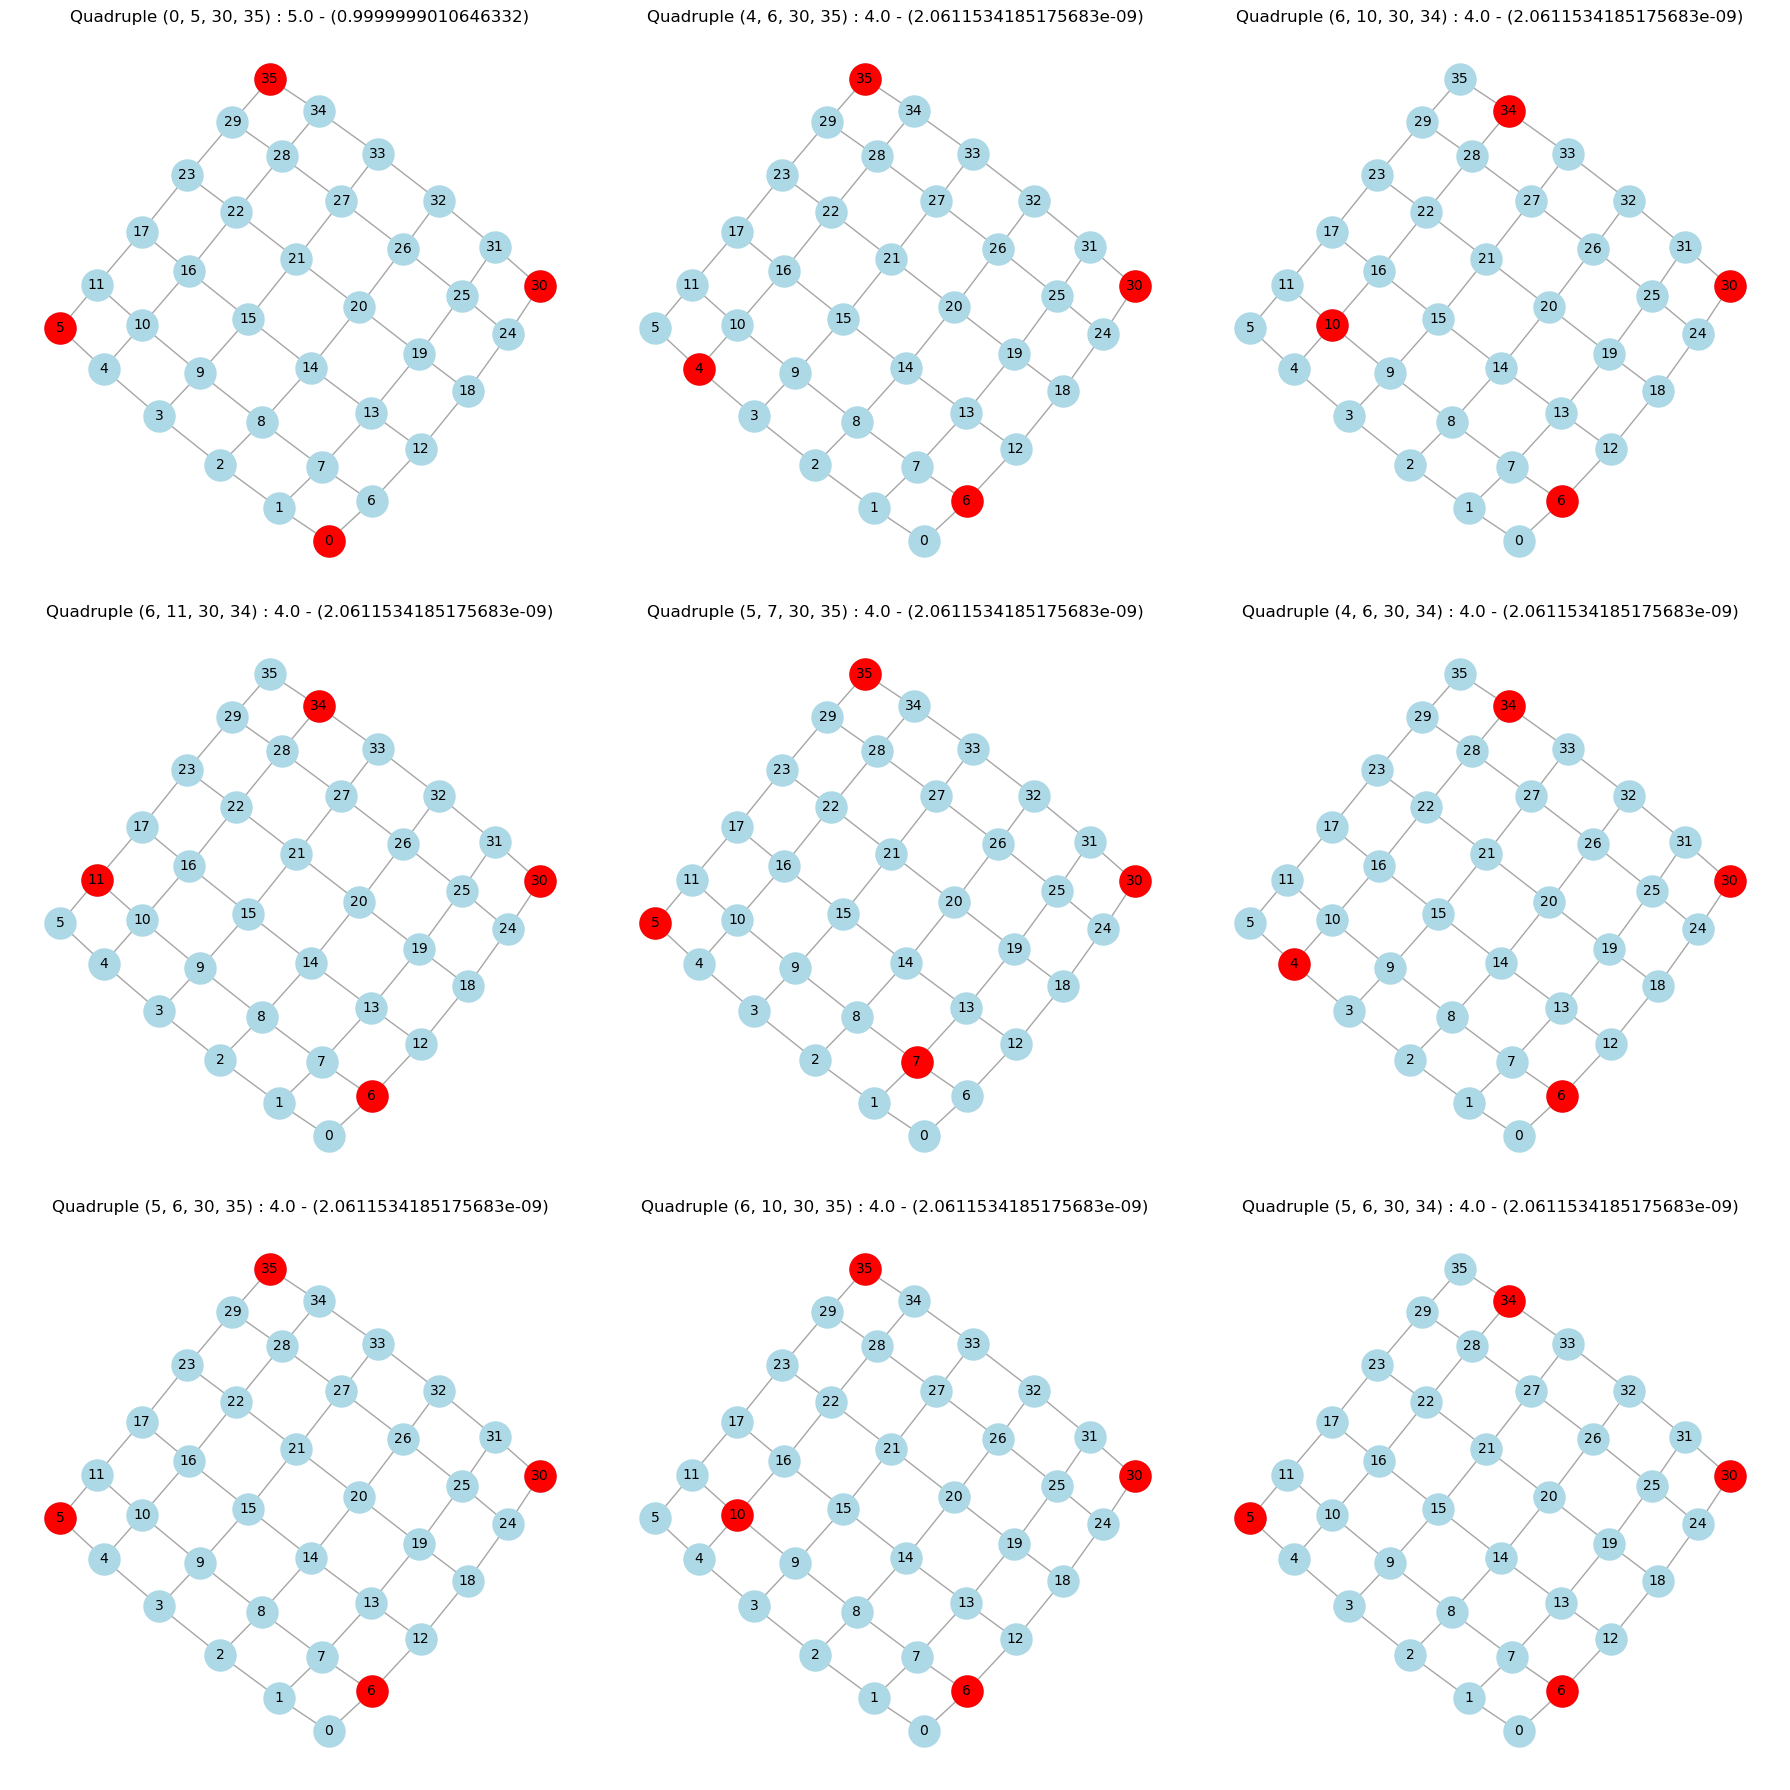

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 5, 30, 35) : 5.0 - (0.9999999010646332)'}>,
        <Axes: title={'center': 'Quadruple (4, 6, 30, 35) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (6, 10, 30, 34) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (6, 11, 30, 34) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (5, 7, 30, 35) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (4, 6, 30, 34) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (5, 6, 30, 35) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (6, 10, 30, 35) : 4.0 - (2.0611534185175683e-09)'}>,
        <Axes: title={'center': 'Quadruple (5, 6, 30, 34) : 4.0 - (2.0611534185175683e-09)'}>],
       dtype=object))

In [5]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

## grid (4,4) with tree (r=2, h=4)

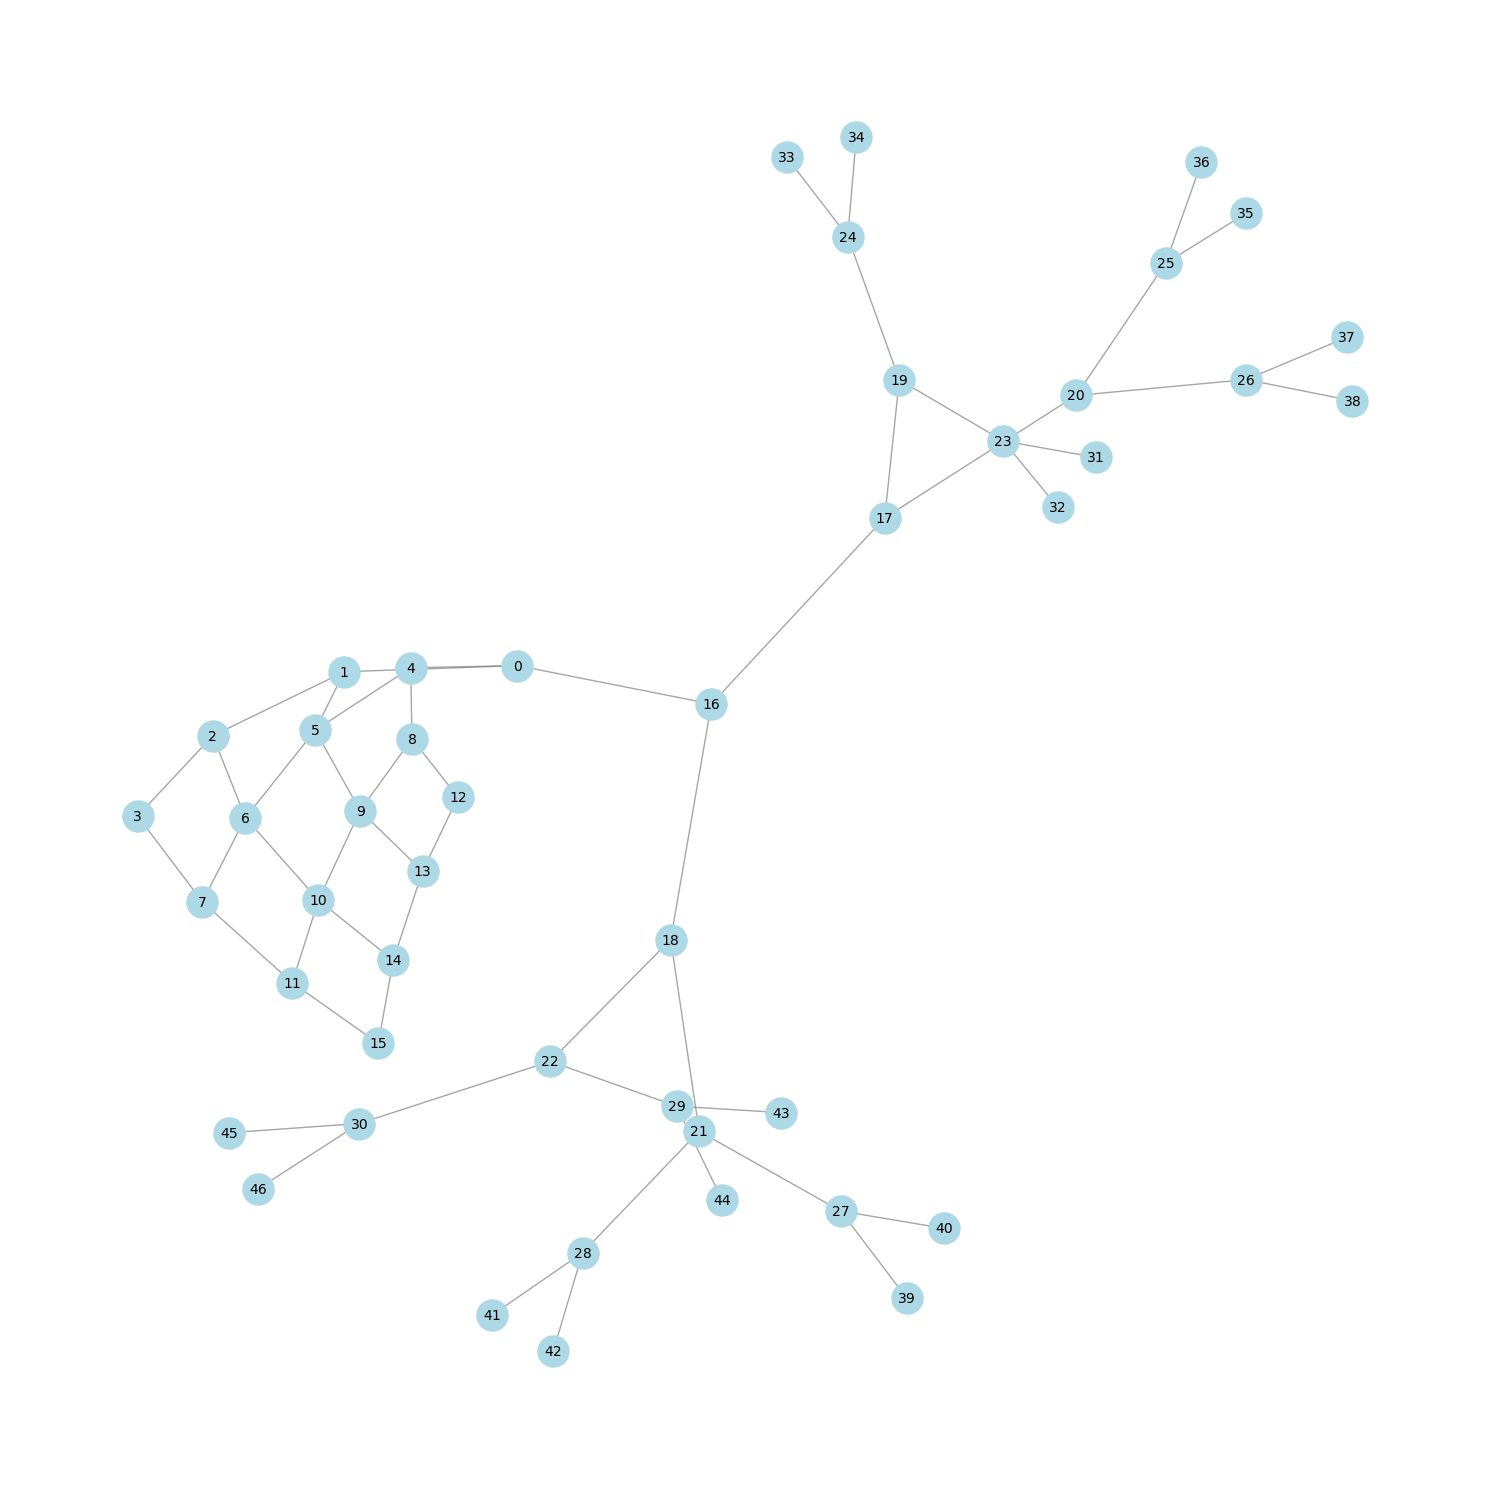

Counter({np.float64(0.0): 171613, np.float64(1.0): 5928, np.float64(2.0): 792, np.float64(3.0): 32})


In [6]:
G = make_tree_with_grid(height_tree=4, leaves_per_node=2, size_grid=4)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(15,15))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

### $\lambda = 2$ , $loc = [16] , [15] , [28] , [6]$

The localized nodes are: [16] and lambda is 2
La cost function e' -0.0005348580493518898 - -0.0006338021268685503: 9.89440775166605e-05
The only data fidelity component mu times delta is: 0.008616141255441504


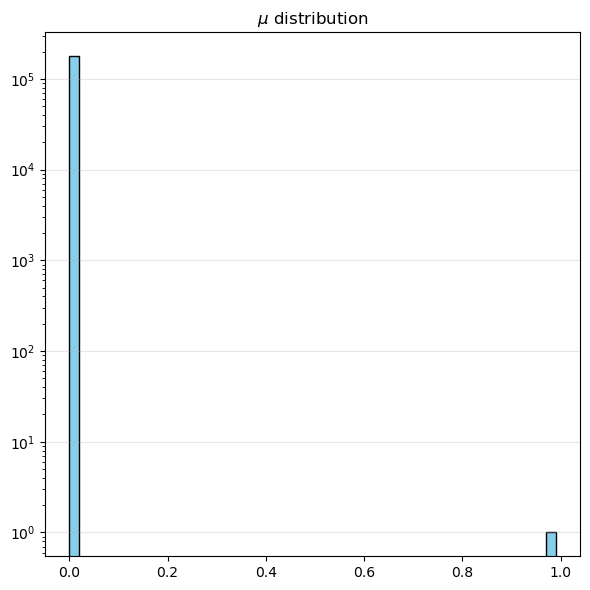

Too many quadruples to visualize (10), showing only the first 9.


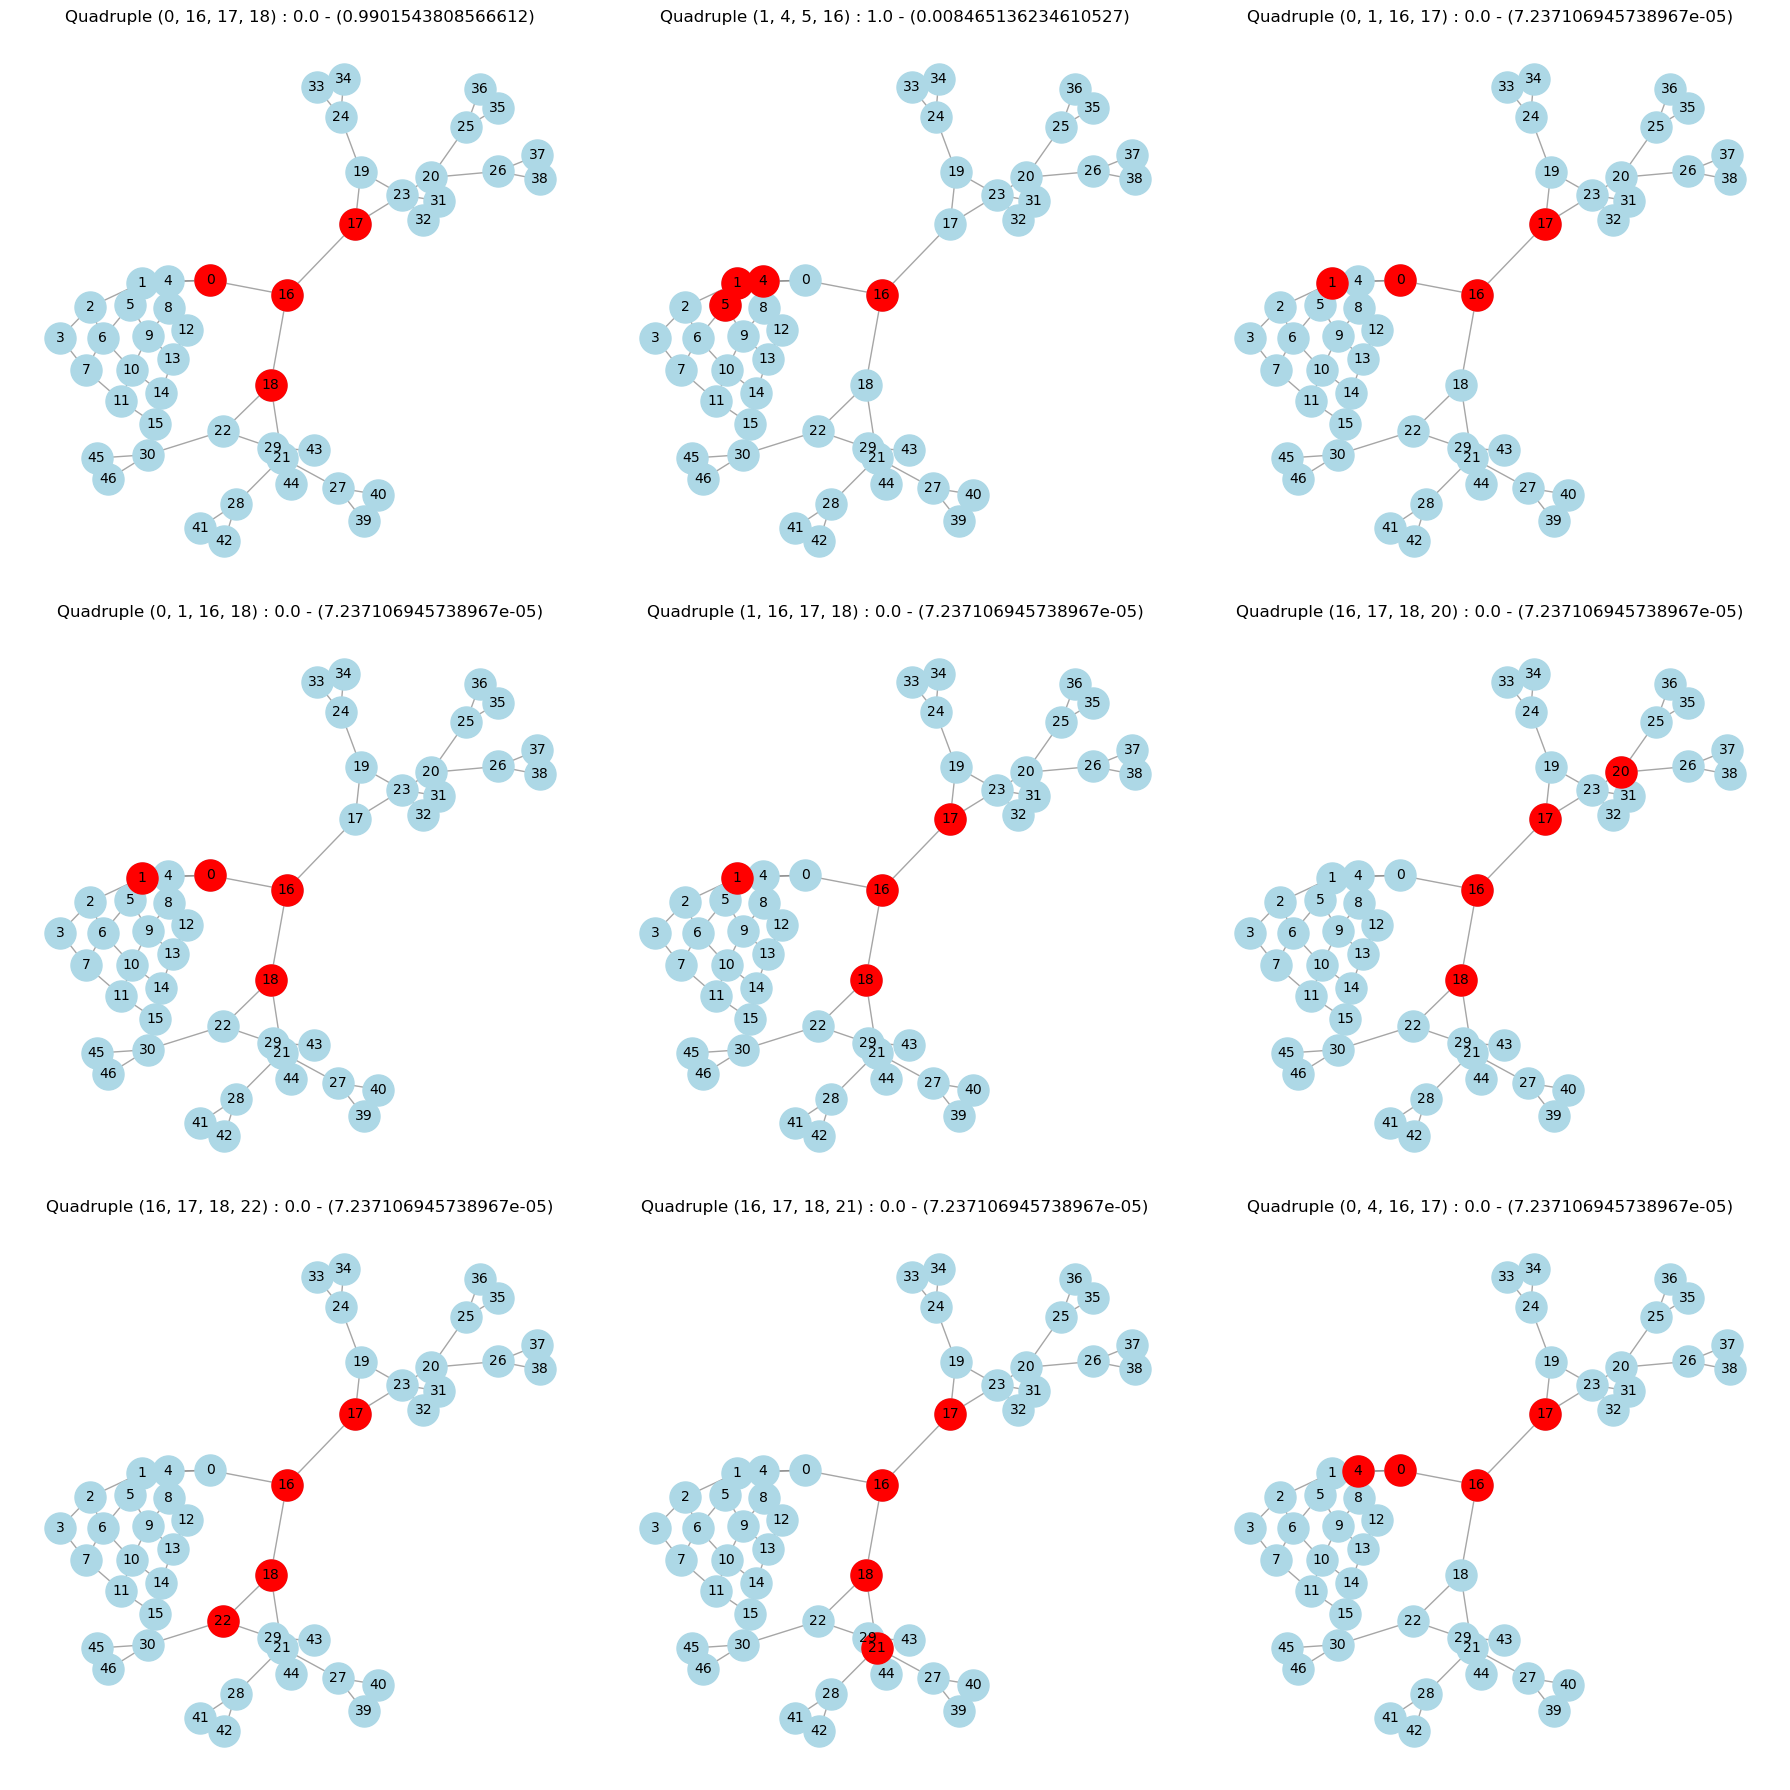

The localized nodes are: [15] and lambda is 2
La cost function e' 0.5996559620625099 - -0.00041212214637147295: 0.6000680842088812
The only data fidelity component mu times delta is: 2.9999983475897953


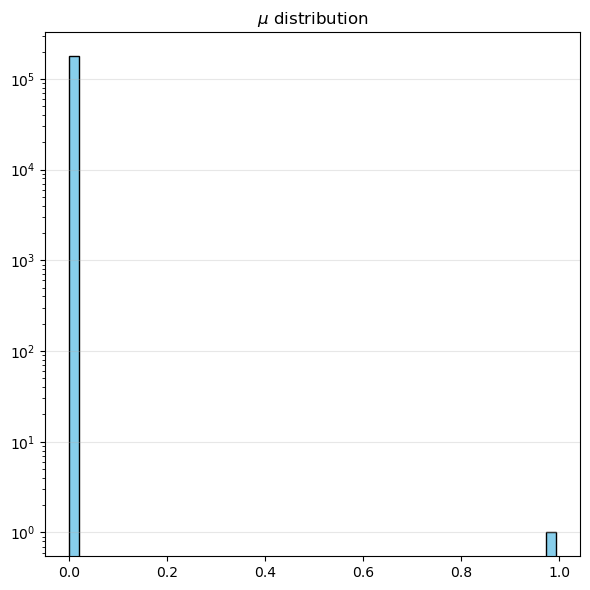

Too many quadruples to visualize (10), showing only the first 9.


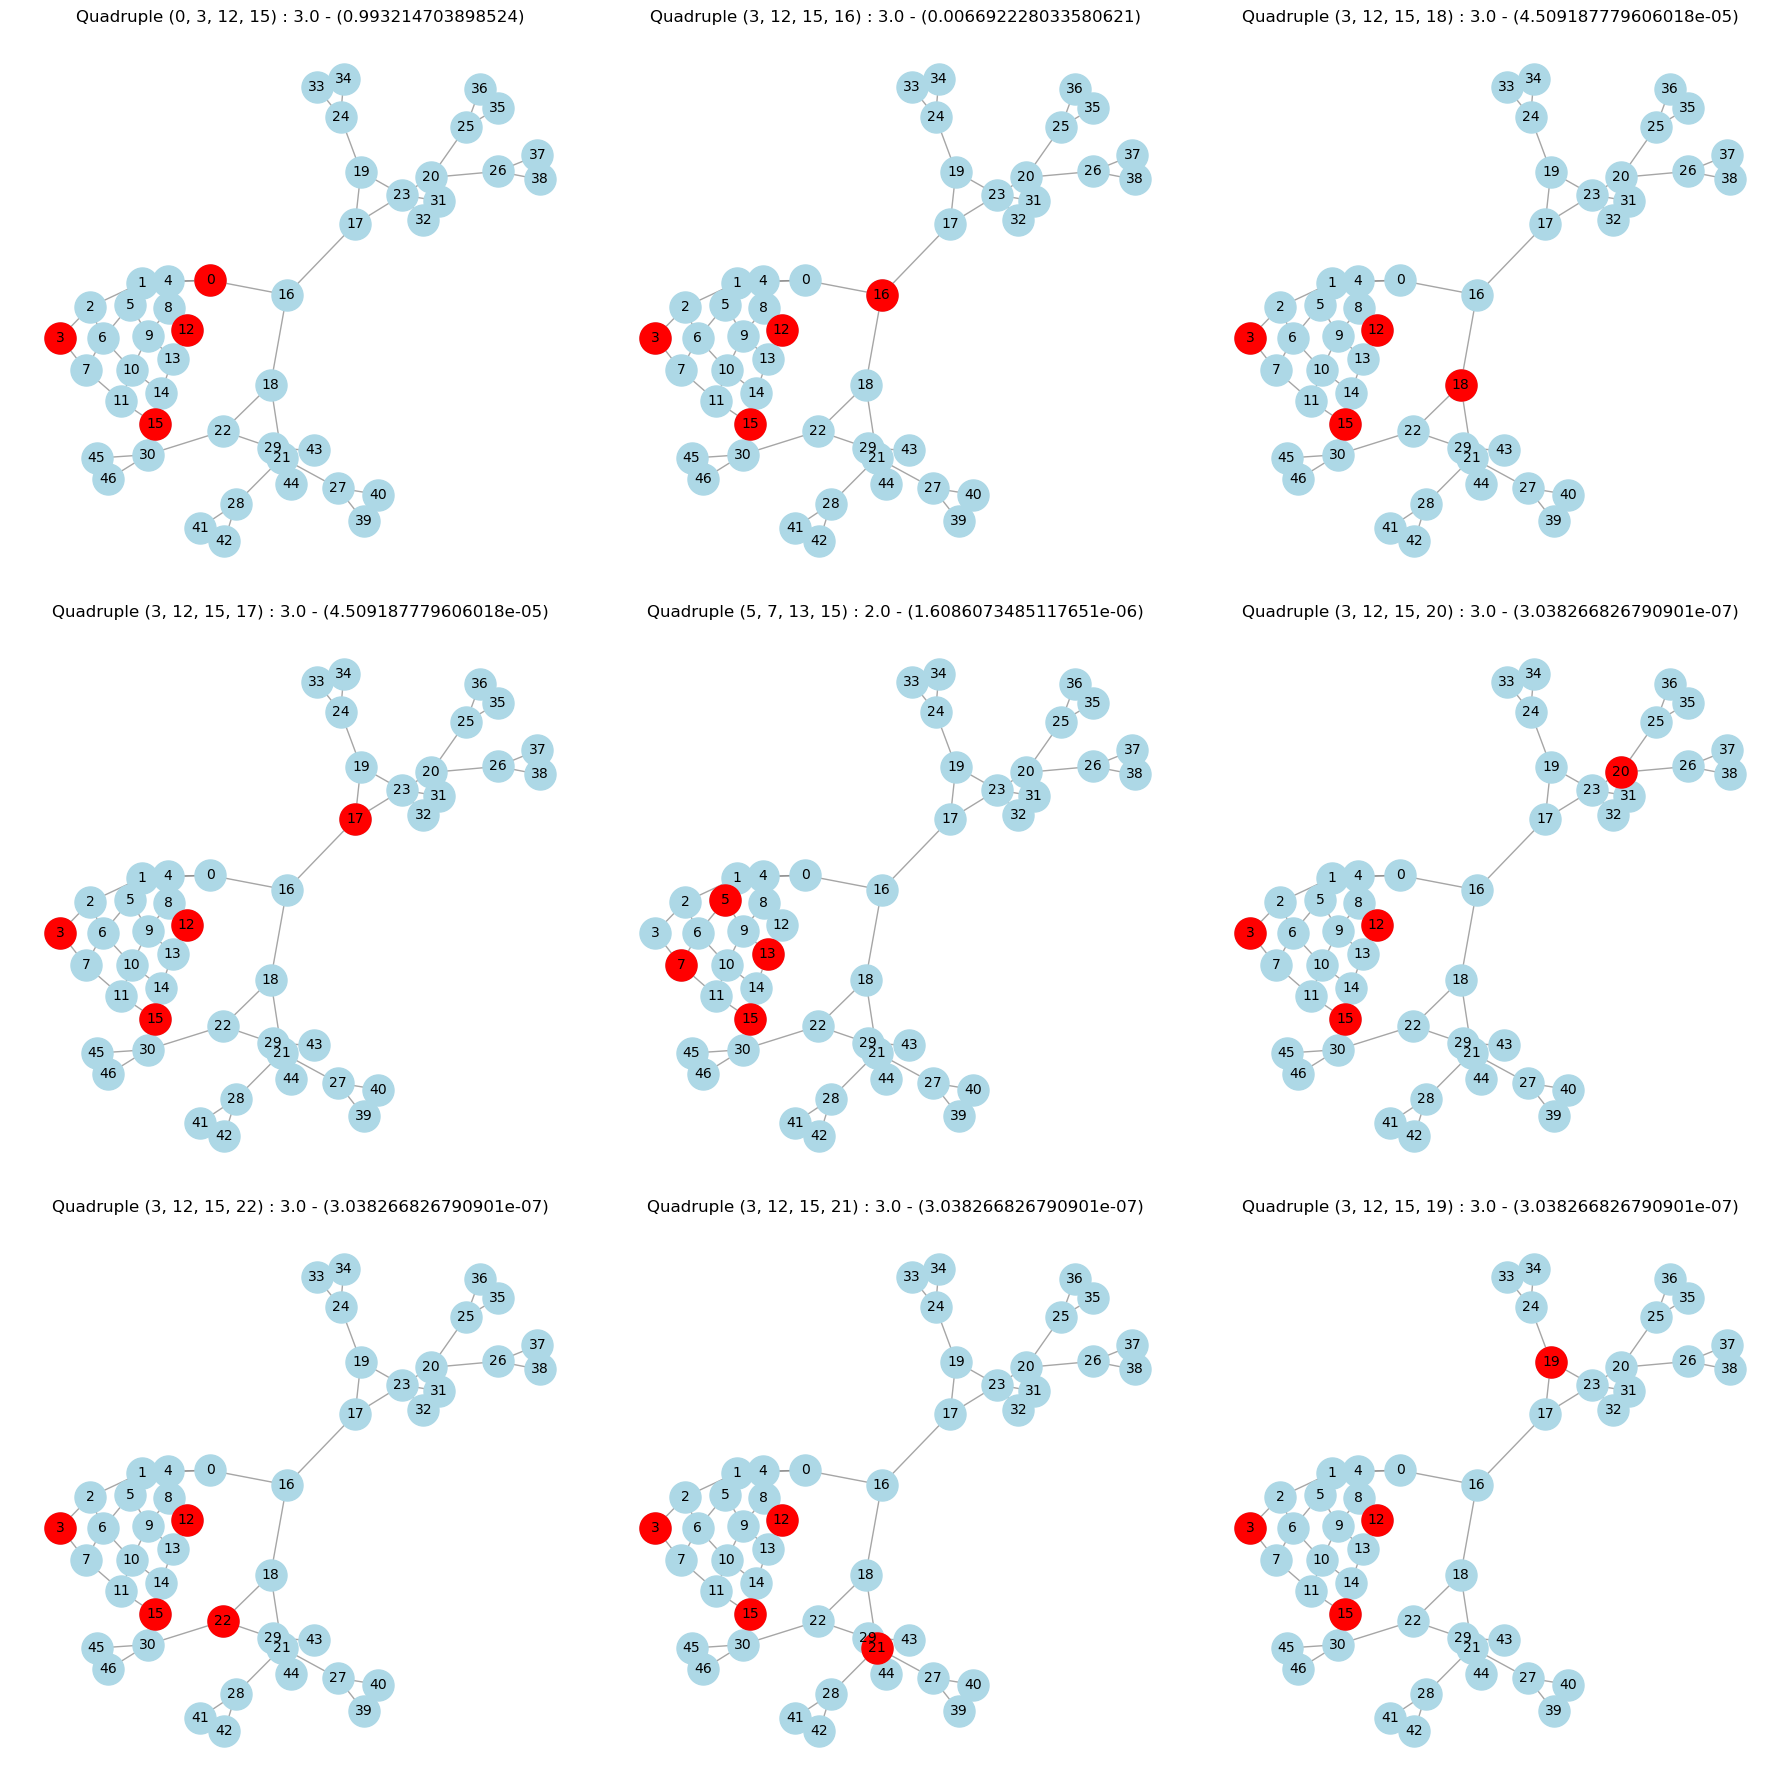

The localized nodes are: [28] and lambda is 2
La cost function e' -0.0008477288971591666 - -0.0009876553064625145: 0.000139926409303348
The only data fidelity component mu times delta is: 4.263006918114859e-12


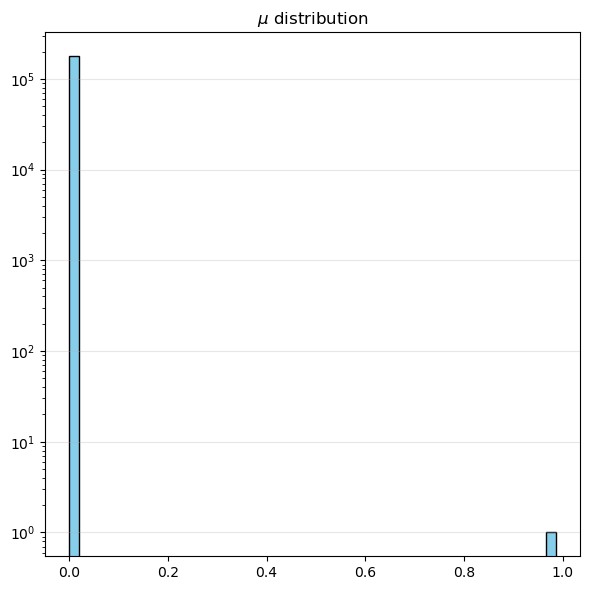

Too many quadruples to visualize (10), showing only the first 9.


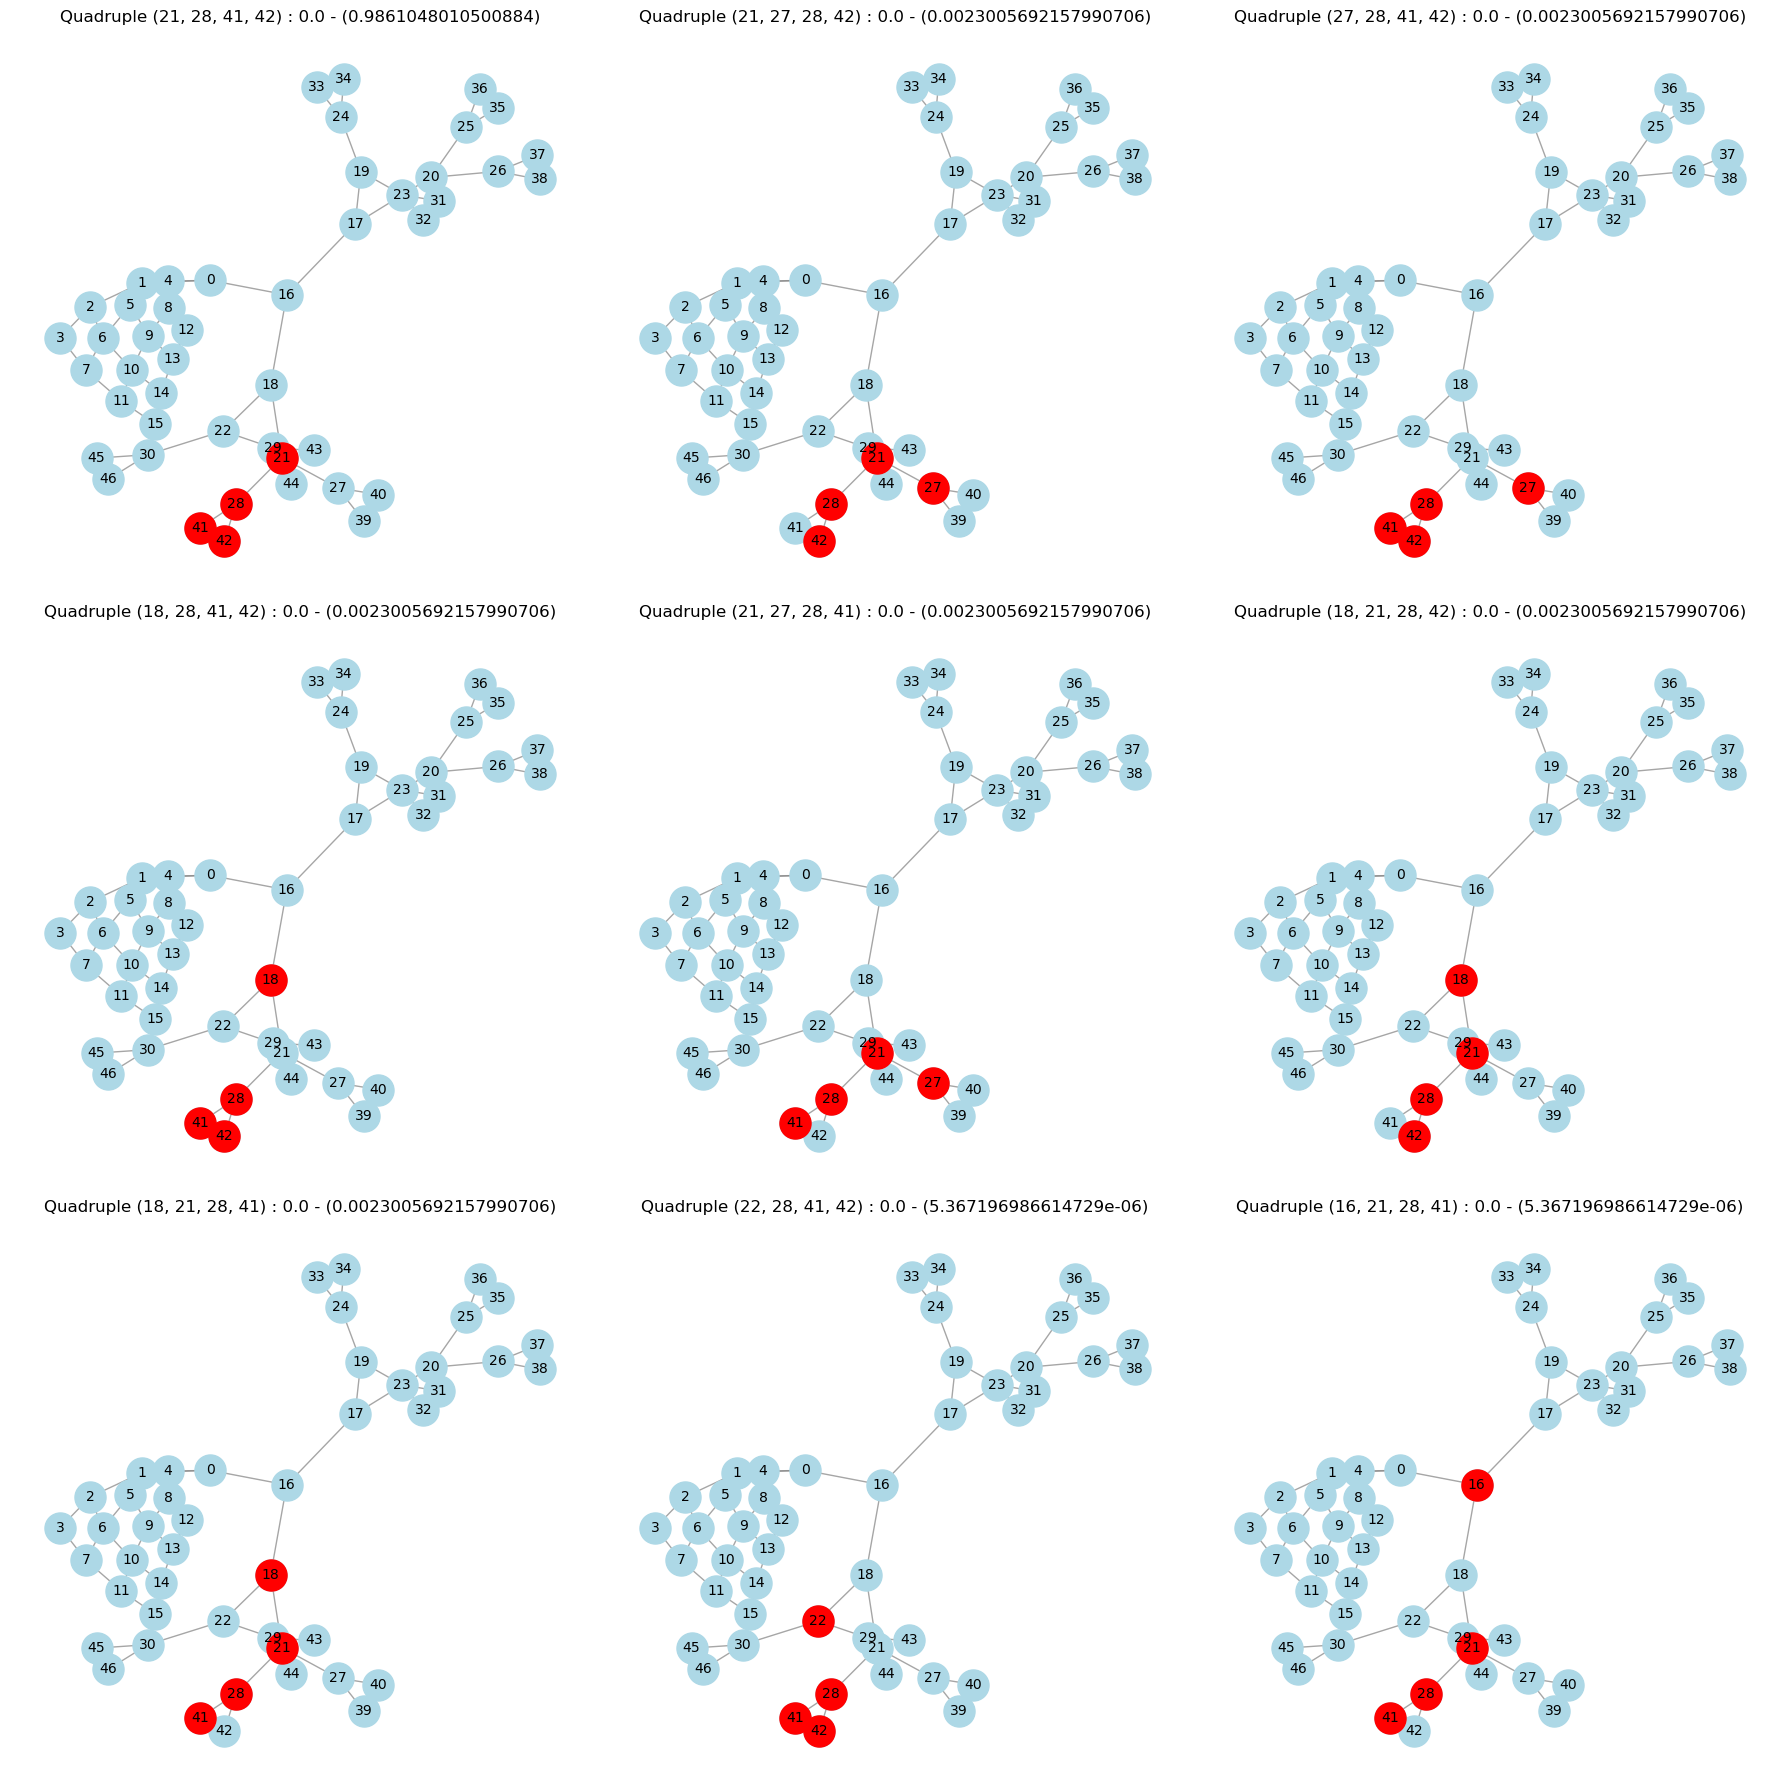

The localized nodes are: [6] and lambda is 2
La cost function e' 0.37850601572263126 - -0.0009421454920978137: 0.37944816121472913
The only data fidelity component mu times delta is: 2.9872718992303233


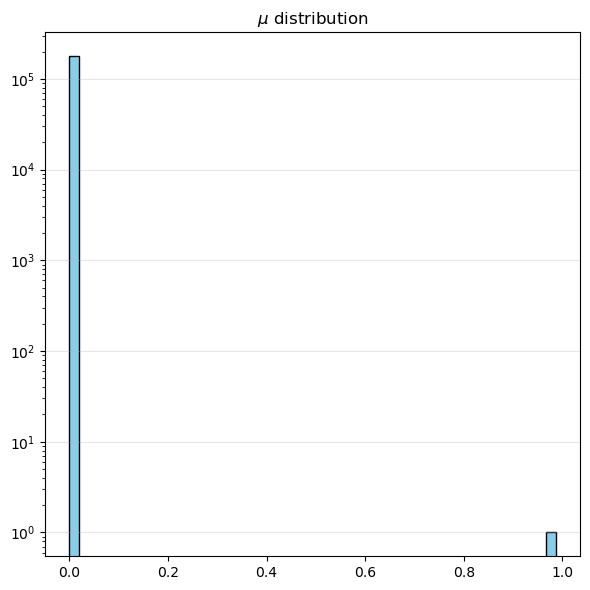

Too many quadruples to visualize (10), showing only the first 9.


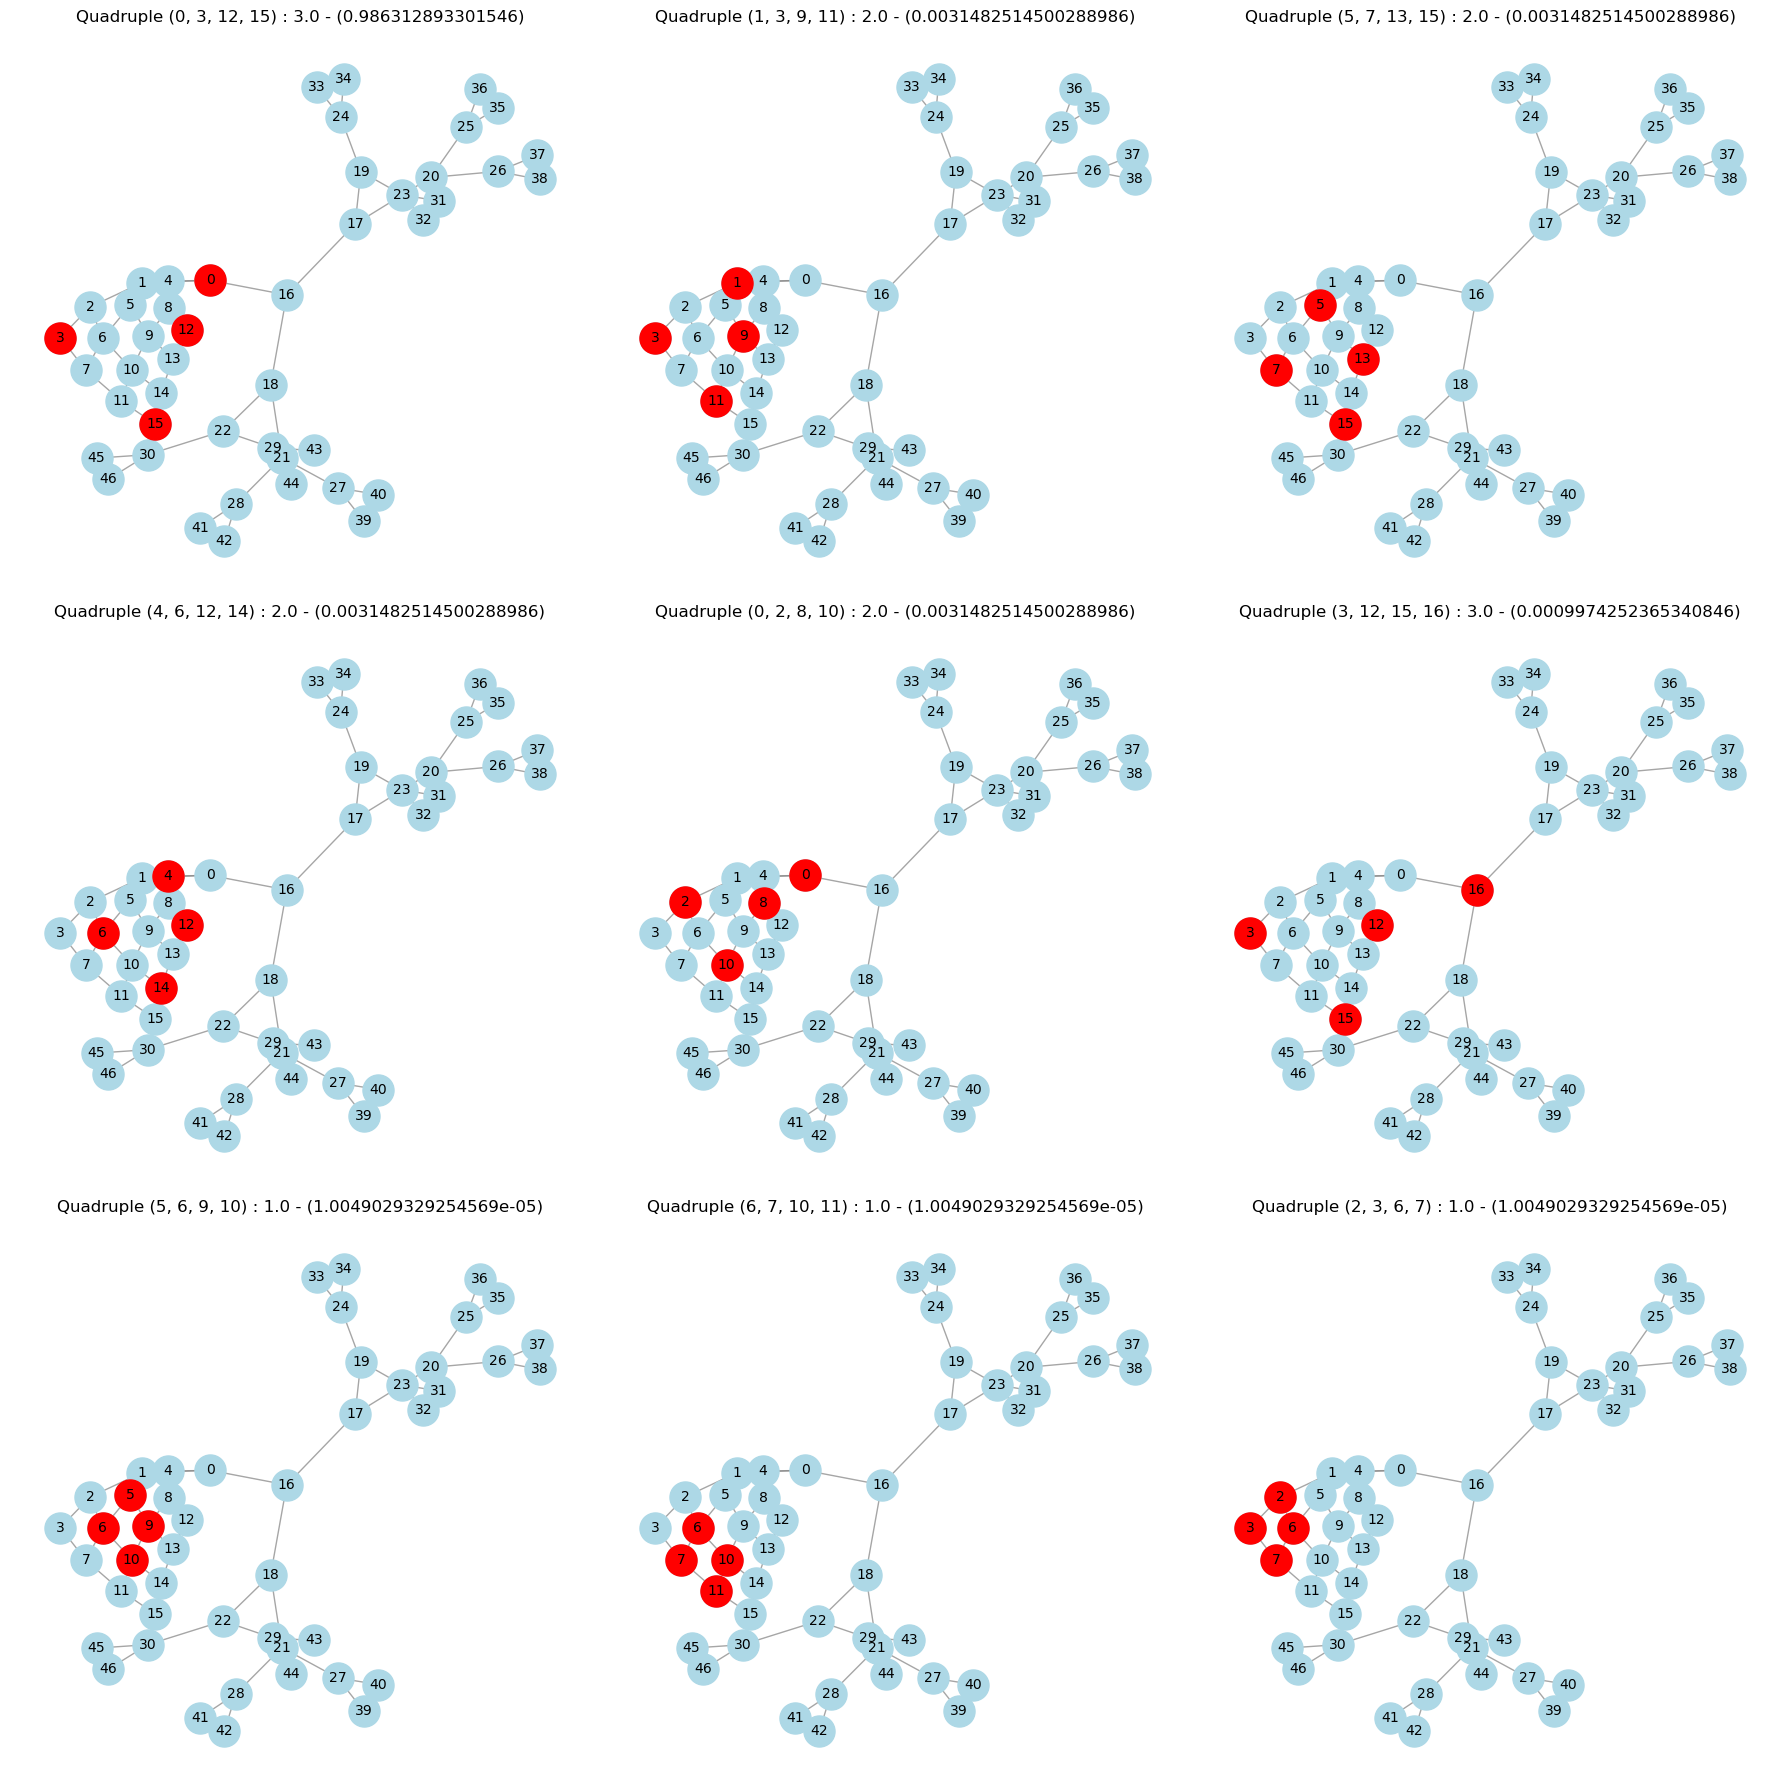

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 3, 12, 15) : 3.0 - (0.986312893301546)'}>,
        <Axes: title={'center': 'Quadruple (1, 3, 9, 11) : 2.0 - (0.0031482514500288986)'}>,
        <Axes: title={'center': 'Quadruple (5, 7, 13, 15) : 2.0 - (0.0031482514500288986)'}>,
        <Axes: title={'center': 'Quadruple (4, 6, 12, 14) : 2.0 - (0.0031482514500288986)'}>,
        <Axes: title={'center': 'Quadruple (0, 2, 8, 10) : 2.0 - (0.0031482514500288986)'}>,
        <Axes: title={'center': 'Quadruple (3, 12, 15, 16) : 3.0 - (0.0009974252365340846)'}>,
        <Axes: title={'center': 'Quadruple (5, 6, 9, 10) : 1.0 - (1.0049029329254569e-05)'}>,
        <Axes: title={'center': 'Quadruple (6, 7, 10, 11) : 1.0 - (1.0049029329254569e-05)'}>,
        <Axes: title={'center': 'Quadruple (2, 3, 6, 7) : 1.0 - (1.0049029329254569e-05)'}>],
       dtype=object))

In [50]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
localized_nodes = [16]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
nom_E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = nom_E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu  + 1e-20)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
localized_nodes = [15]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
nom_E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = nom_E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu  + 1e-20)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)


localized_nodes = [28]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
nom_E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = nom_E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu  + 1e-20)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

localized_nodes = [6]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
nom_E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = nom_E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu  + 1e-20)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

## grid (6,6) with tree (r=3 , h=3)

In [ ]:
G = make_tree_with_grid(height_tree=3, leaves_per_node=3, size_grid=6)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

### first run without locality

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()

E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

In [ ]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

### second run with locality $\lambda = 1.5$, loc = [21]

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

In [ ]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

## random geometric n = 120, radius = 0.15

Is G connected? True


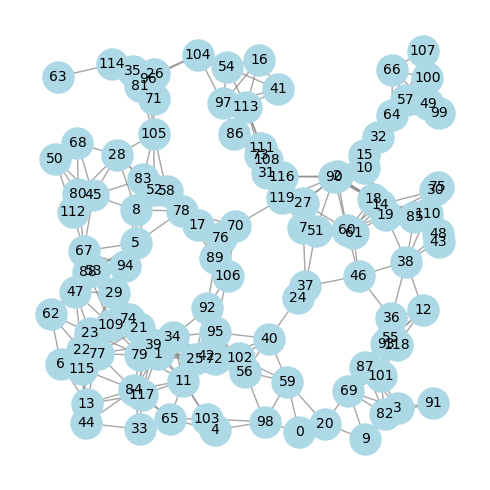

Counter({np.float64(0.0): 3673575, np.float64(0.5): 2575815, np.float64(1.0): 1200367, np.float64(1.5): 519674, np.float64(2.0): 200636, np.float64(2.5): 42082, np.float64(3.0): 2414, np.float64(3.5): 7})


In [51]:
G,pos = create_geometric_graph(n=120, radius=0.15)
print(f"Is G connected? {nx.is_connected(G)}")
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

### first run without locality

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()

E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov 

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

### second run wih locality $\lambda = 2$ and loc = [24]

The localized nodes are: [24] and lambda is 2
The only data fidelity component mu times delta is: 2.000016864765982
La cost function e' 0.29481805813989953 - -0.011842776692211857: 0.30666083483211143


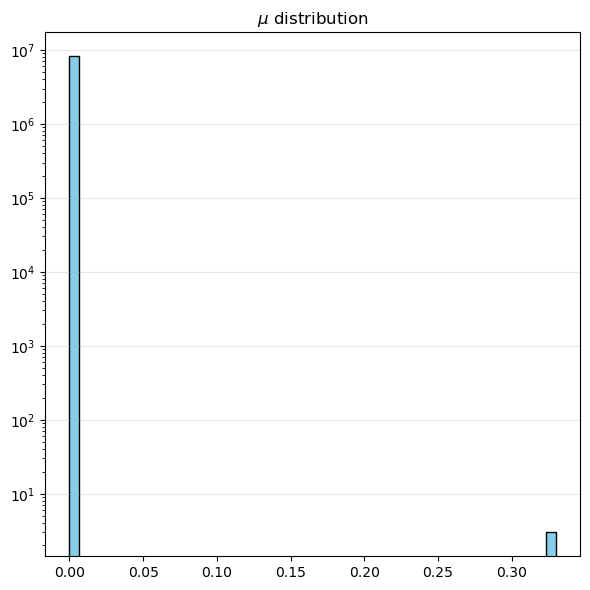

Too many quadruples to visualize (10), showing only the first 9.


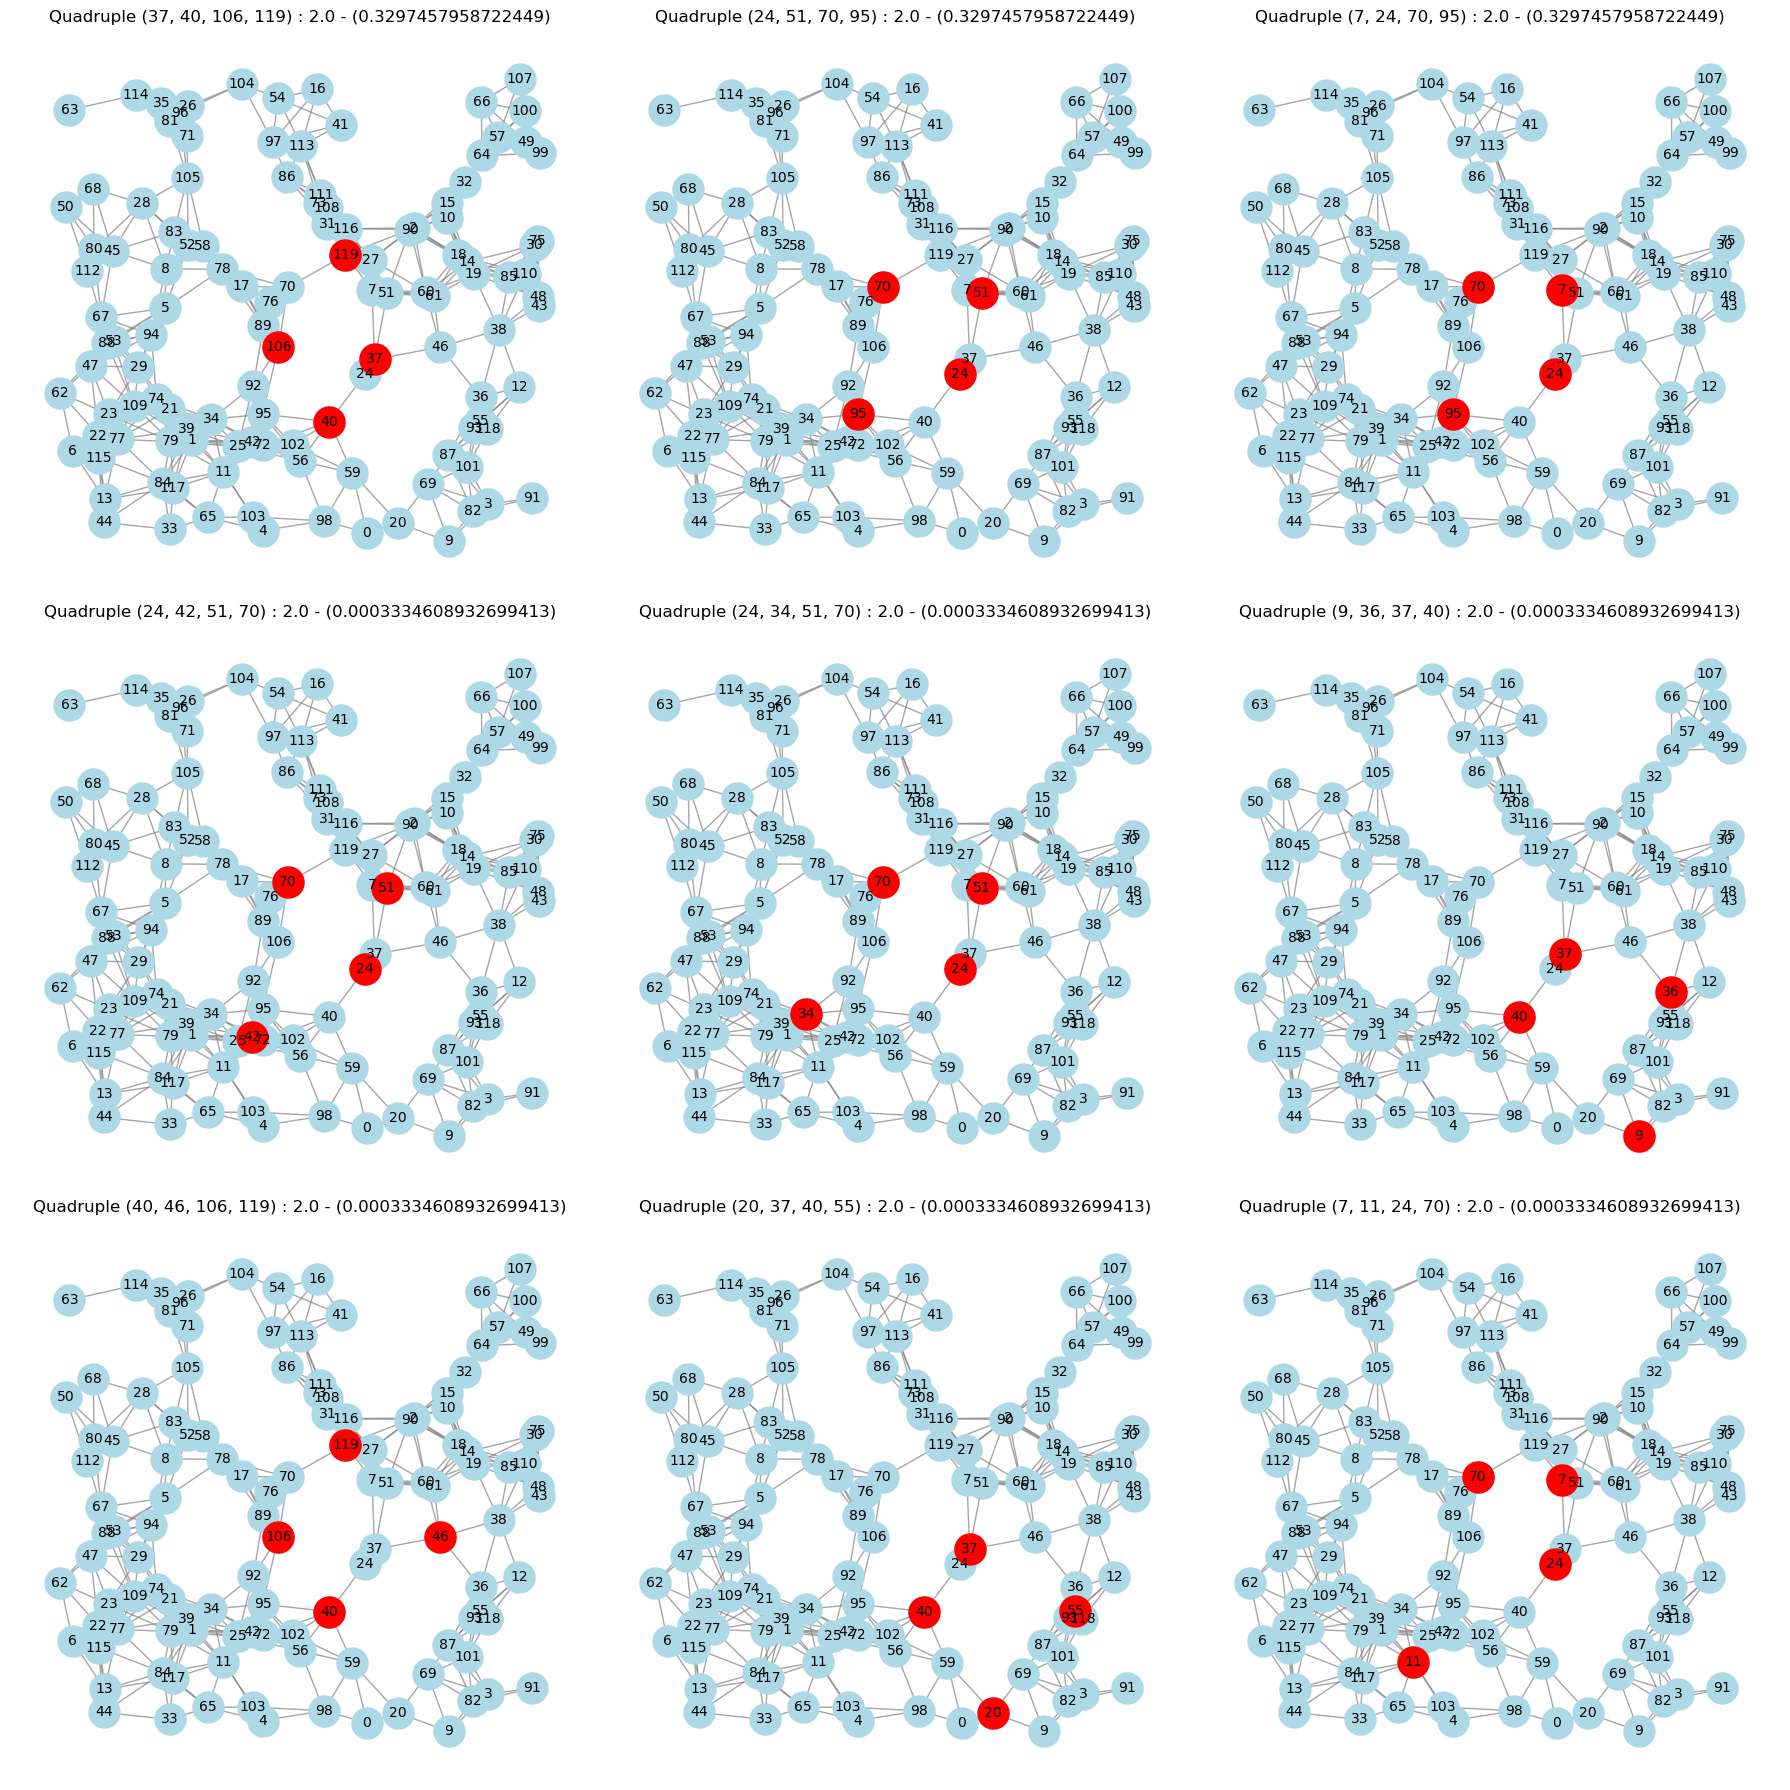

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (37, 40, 106, 119) : 2.0 - (0.3297457958722449)'}>,
        <Axes: title={'center': 'Quadruple (24, 51, 70, 95) : 2.0 - (0.3297457958722449)'}>,
        <Axes: title={'center': 'Quadruple (7, 24, 70, 95) : 2.0 - (0.3297457958722449)'}>,
        <Axes: title={'center': 'Quadruple (24, 42, 51, 70) : 2.0 - (0.0003334608932699413)'}>,
        <Axes: title={'center': 'Quadruple (24, 34, 51, 70) : 2.0 - (0.0003334608932699413)'}>,
        <Axes: title={'center': 'Quadruple (9, 36, 37, 40) : 2.0 - (0.0003334608932699413)'}>,
        <Axes: title={'center': 'Quadruple (40, 46, 106, 119) : 2.0 - (0.0003334608932699413)'}>,
        <Axes: title={'center': 'Quadruple (20, 37, 40, 55) : 2.0 - (0.0003334608932699413)'}>,
        <Axes: title={'center': 'Quadruple (7, 11, 24, 70) : 2.0 - (0.0003334608932699413)'}>],
       dtype=object))

In [53]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
lambda_reg = 2
localized_nodes = [24]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
real_gromov = E_gromov.copy()
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"The only data fidelity component mu times delta is: {np.sum(mu * real_gromov)}")
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

### loc = [67], $\lambda = 1.5$

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

## tree of cycle 

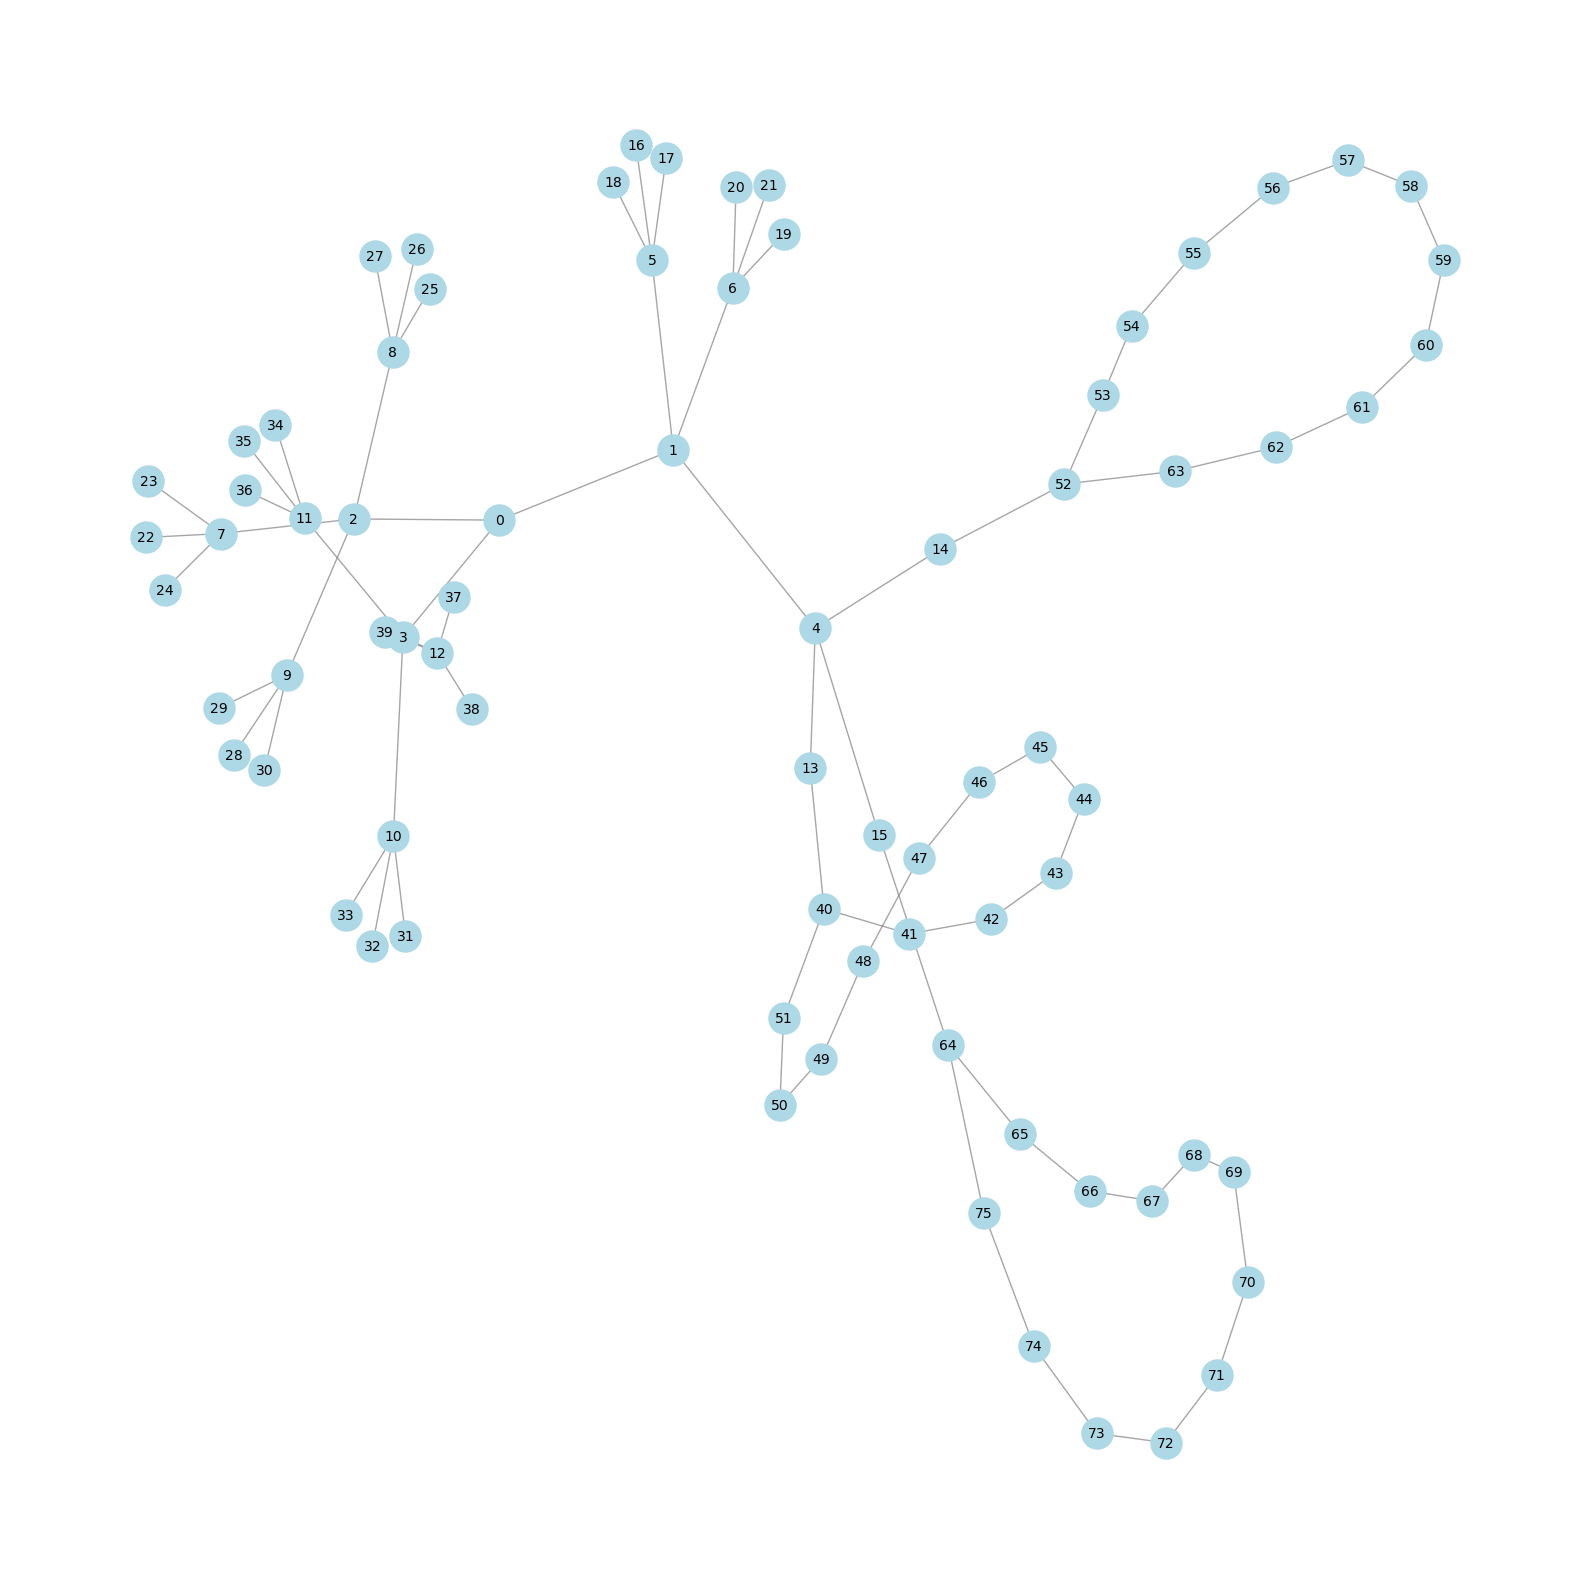

Counter({np.float64(0.0): 1265890, np.float64(1.0): 13266, np.float64(2.0): 3618, np.float64(3.0): 201})


In [7]:
G, _ = make_tree_of_cycles(cycle_size=12,tree_height=3, branching=3,n_cycles=3)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(16,16))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

### locality with [0] and $\lambda = 1.7$

The localized nodes are: [0] and lambda is 1.7
La cost function e' 0.0044317191415265324 - -0.016789368037578477: 0.021221087179105015
The only data fidelity component mu times delta is: 0.8494936057735707


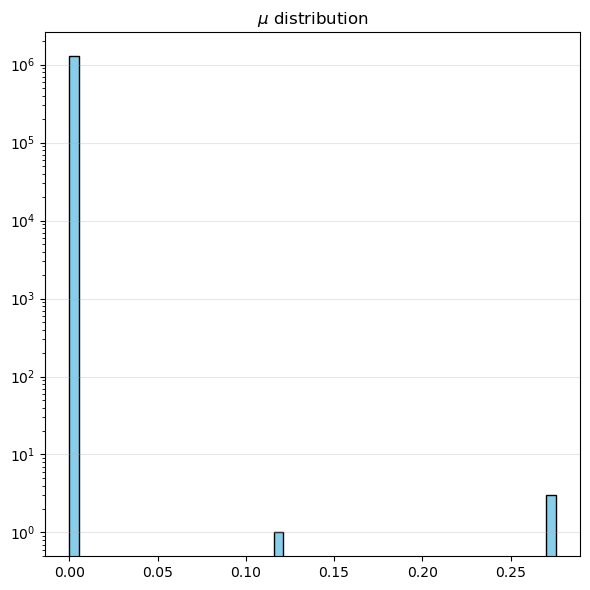

Too many quadruples to visualize (10), showing only the first 9.


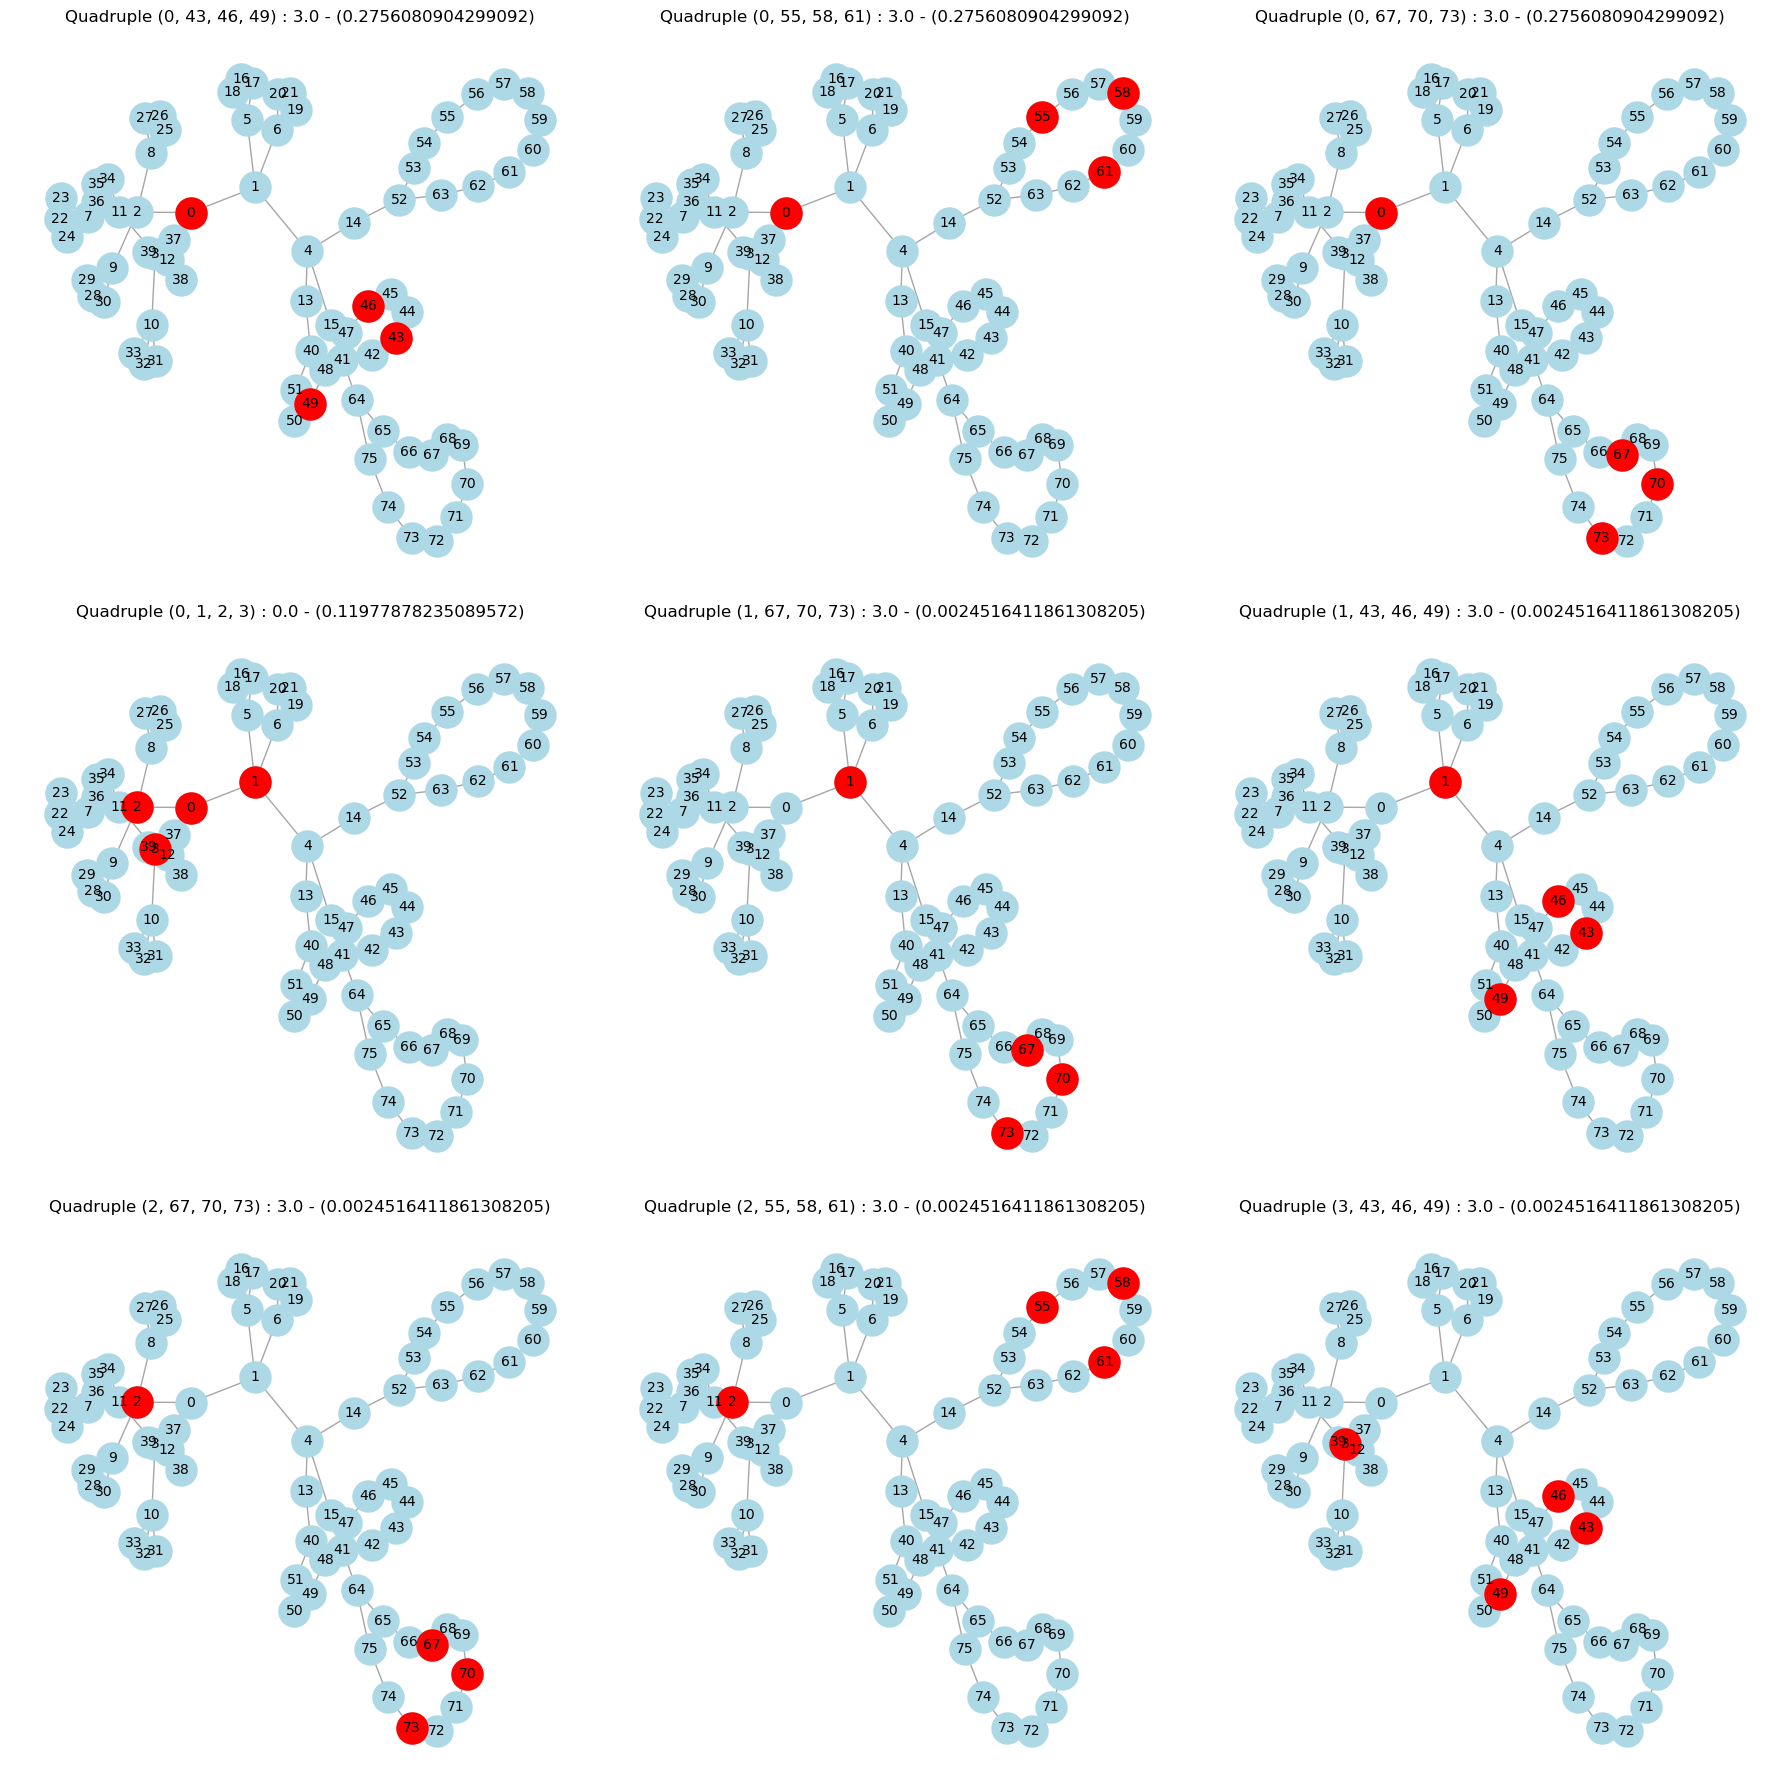

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 43, 46, 49) : 3.0 - (0.2756080904299092)'}>,
        <Axes: title={'center': 'Quadruple (0, 55, 58, 61) : 3.0 - (0.2756080904299092)'}>,
        <Axes: title={'center': 'Quadruple (0, 67, 70, 73) : 3.0 - (0.2756080904299092)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 3) : 0.0 - (0.11977878235089572)'}>,
        <Axes: title={'center': 'Quadruple (1, 67, 70, 73) : 3.0 - (0.0024516411861308205)'}>,
        <Axes: title={'center': 'Quadruple (1, 43, 46, 49) : 3.0 - (0.0024516411861308205)'}>,
        <Axes: title={'center': 'Quadruple (2, 67, 70, 73) : 3.0 - (0.0024516411861308205)'}>,
        <Axes: title={'center': 'Quadruple (2, 55, 58, 61) : 3.0 - (0.0024516411861308205)'}>,
        <Axes: title={'center': 'Quadruple (3, 43, 46, 49) : 3.0 - (0.0024516411861308205)'}>],
       dtype=object))

In [11]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
lambda_reg = 1.7
localized_nodes = [0]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

### locality with [0], $\lambda = 2$

The localized nodes are: [0] and lambda is 2
La cost function e' -0.005541904767425878 - -0.0065620105888602315: 0.0010201058214343538
The only data fidelity component mu times delta is: 1.5835928379223014e-07


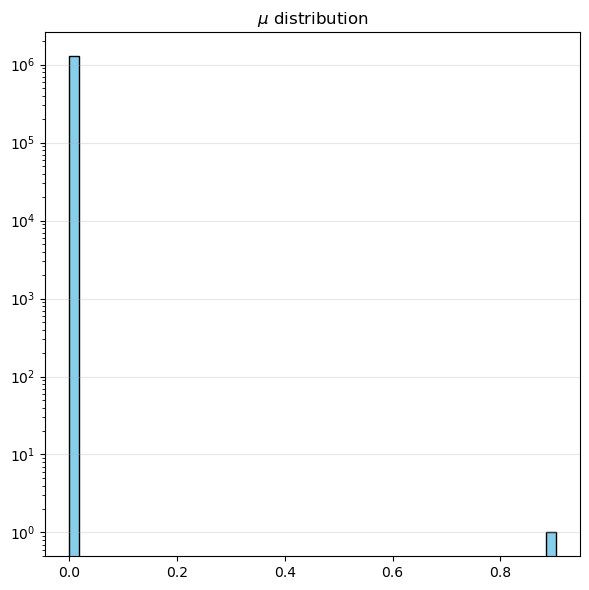

Too many quadruples to visualize (10), showing only the first 9.


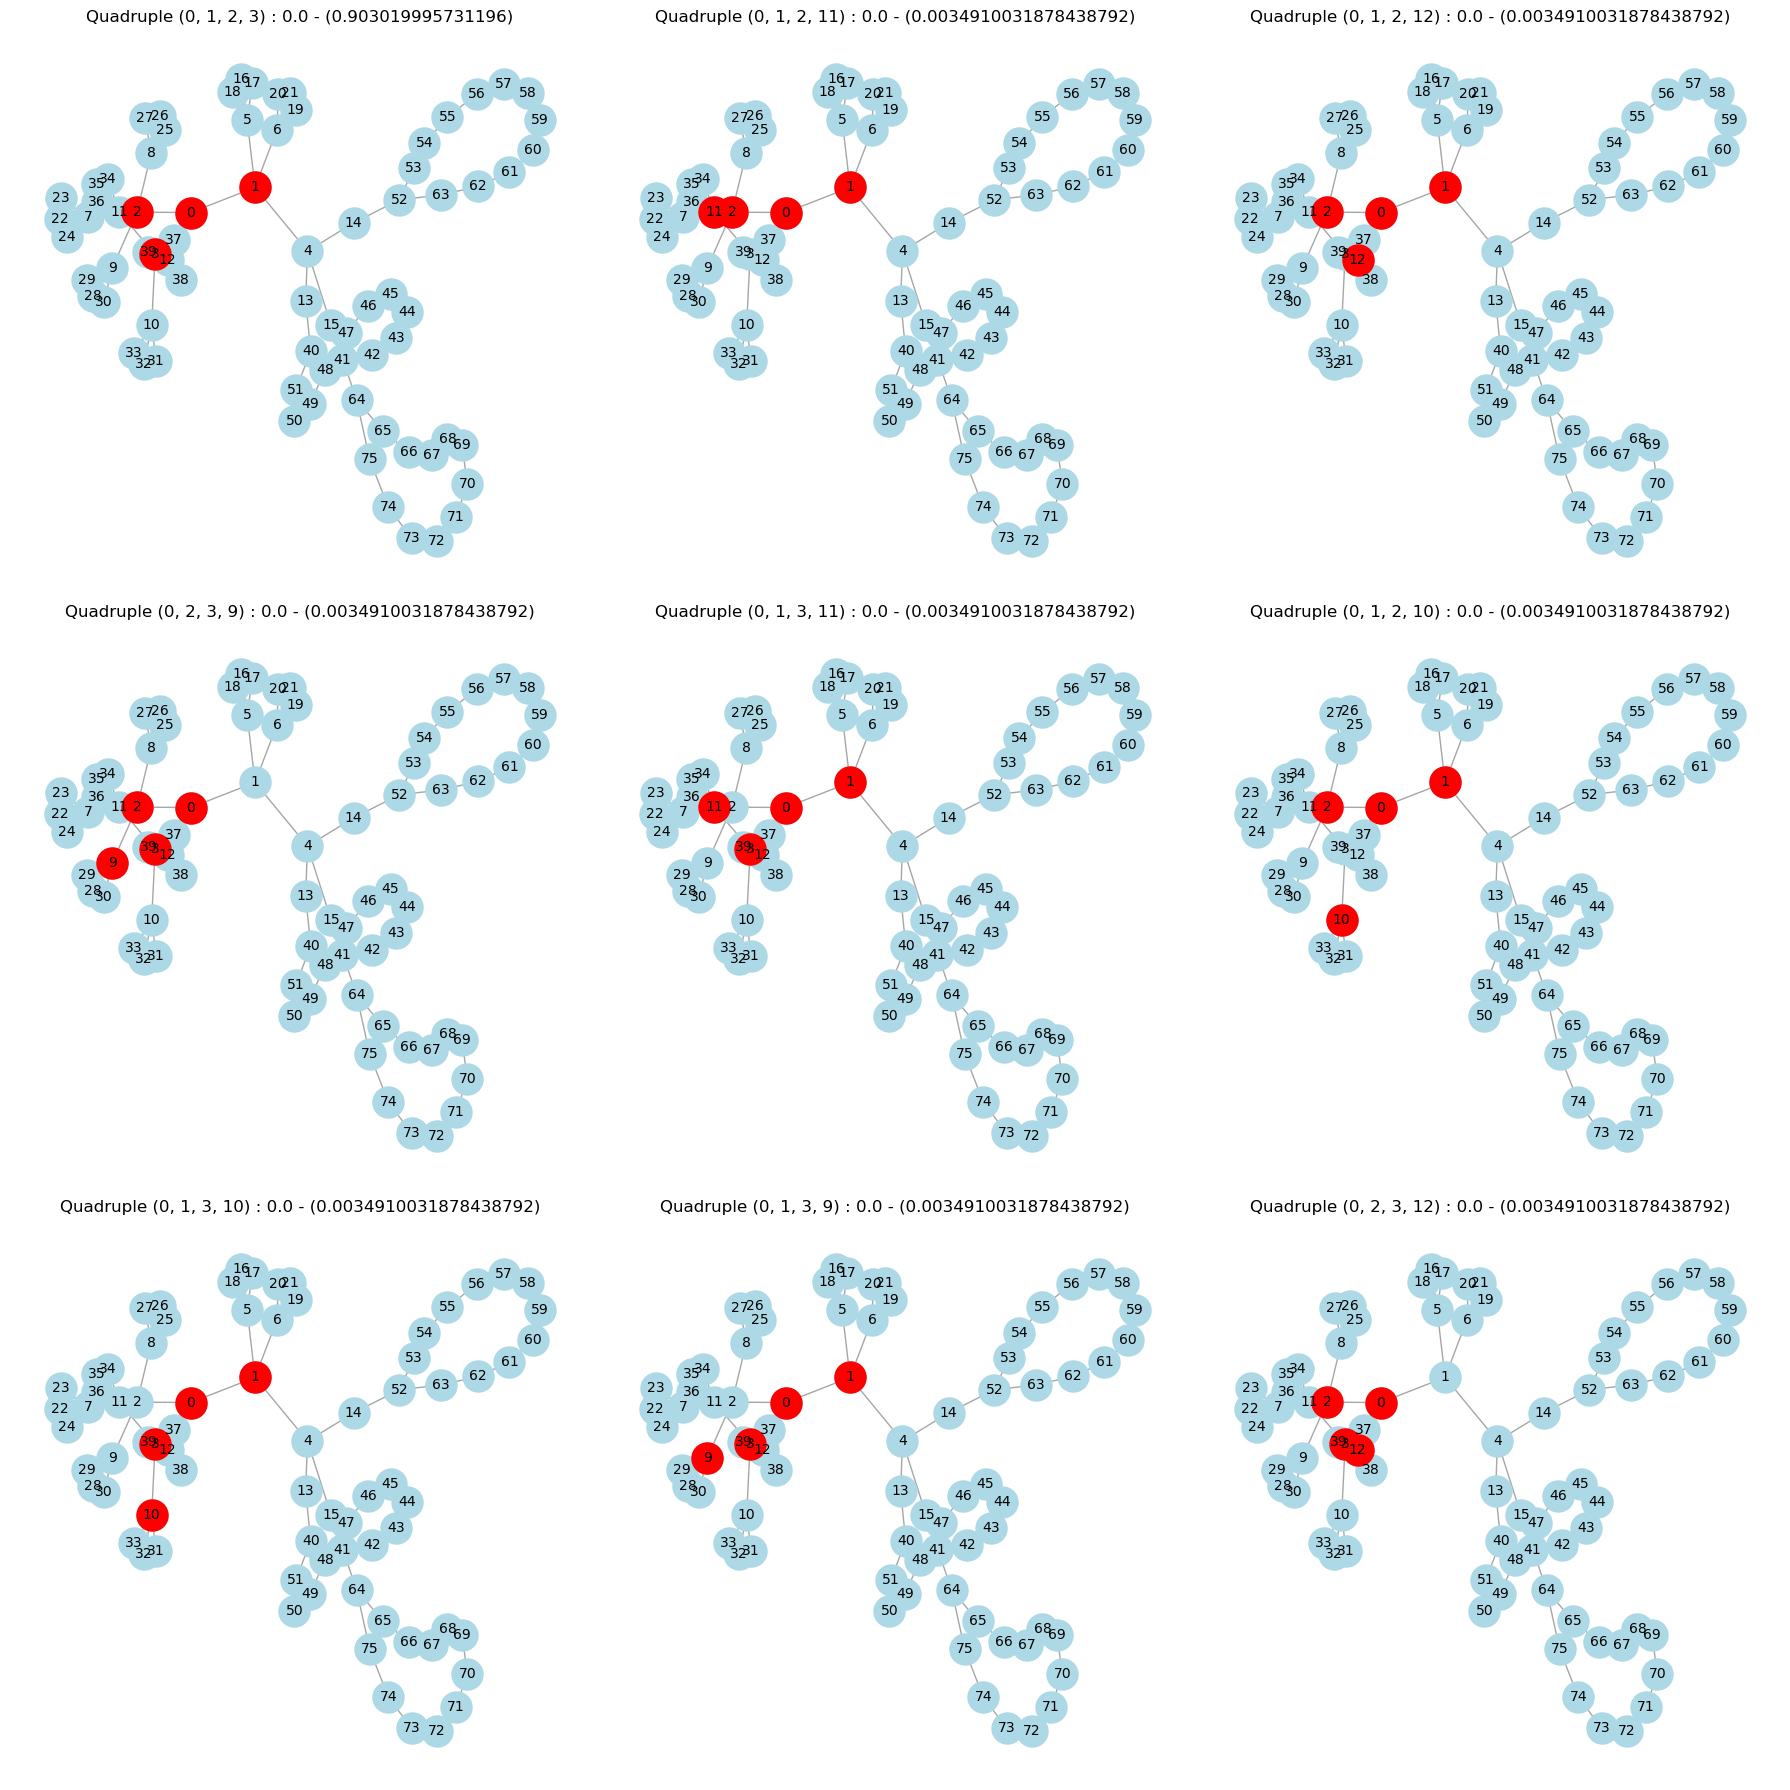

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (0, 1, 2, 3) : 0.0 - (0.903019995731196)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 11) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 12) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 2, 3, 9) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 3, 11) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 2, 10) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 3, 10) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 1, 3, 9) : 0.0 - (0.0034910031878438792)'}>,
        <Axes: title={'center': 'Quadruple (0, 2, 3, 12) : 0.0 - (0.0034910031878438792)'}>],
       dtype=object))

In [12]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
lambda_reg = 2
localized_nodes = [0]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
E_gromov = normalize(E_gromov)
W_local = normalize(W_local)

cost_vector = E_gromov - lambda_reg * W_local

mu = solve_entropic_regularization(cost_vector, temperature)

first_term = mu * cost_vector
second_term = temperature * mu * np.log(mu)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")

plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

# trying again with l2 reg

$$\max_\mu \sum_i \mu_i \delta(h_i) - \lambda  ||\mu - d||_2^2$$

## graph inizialization 

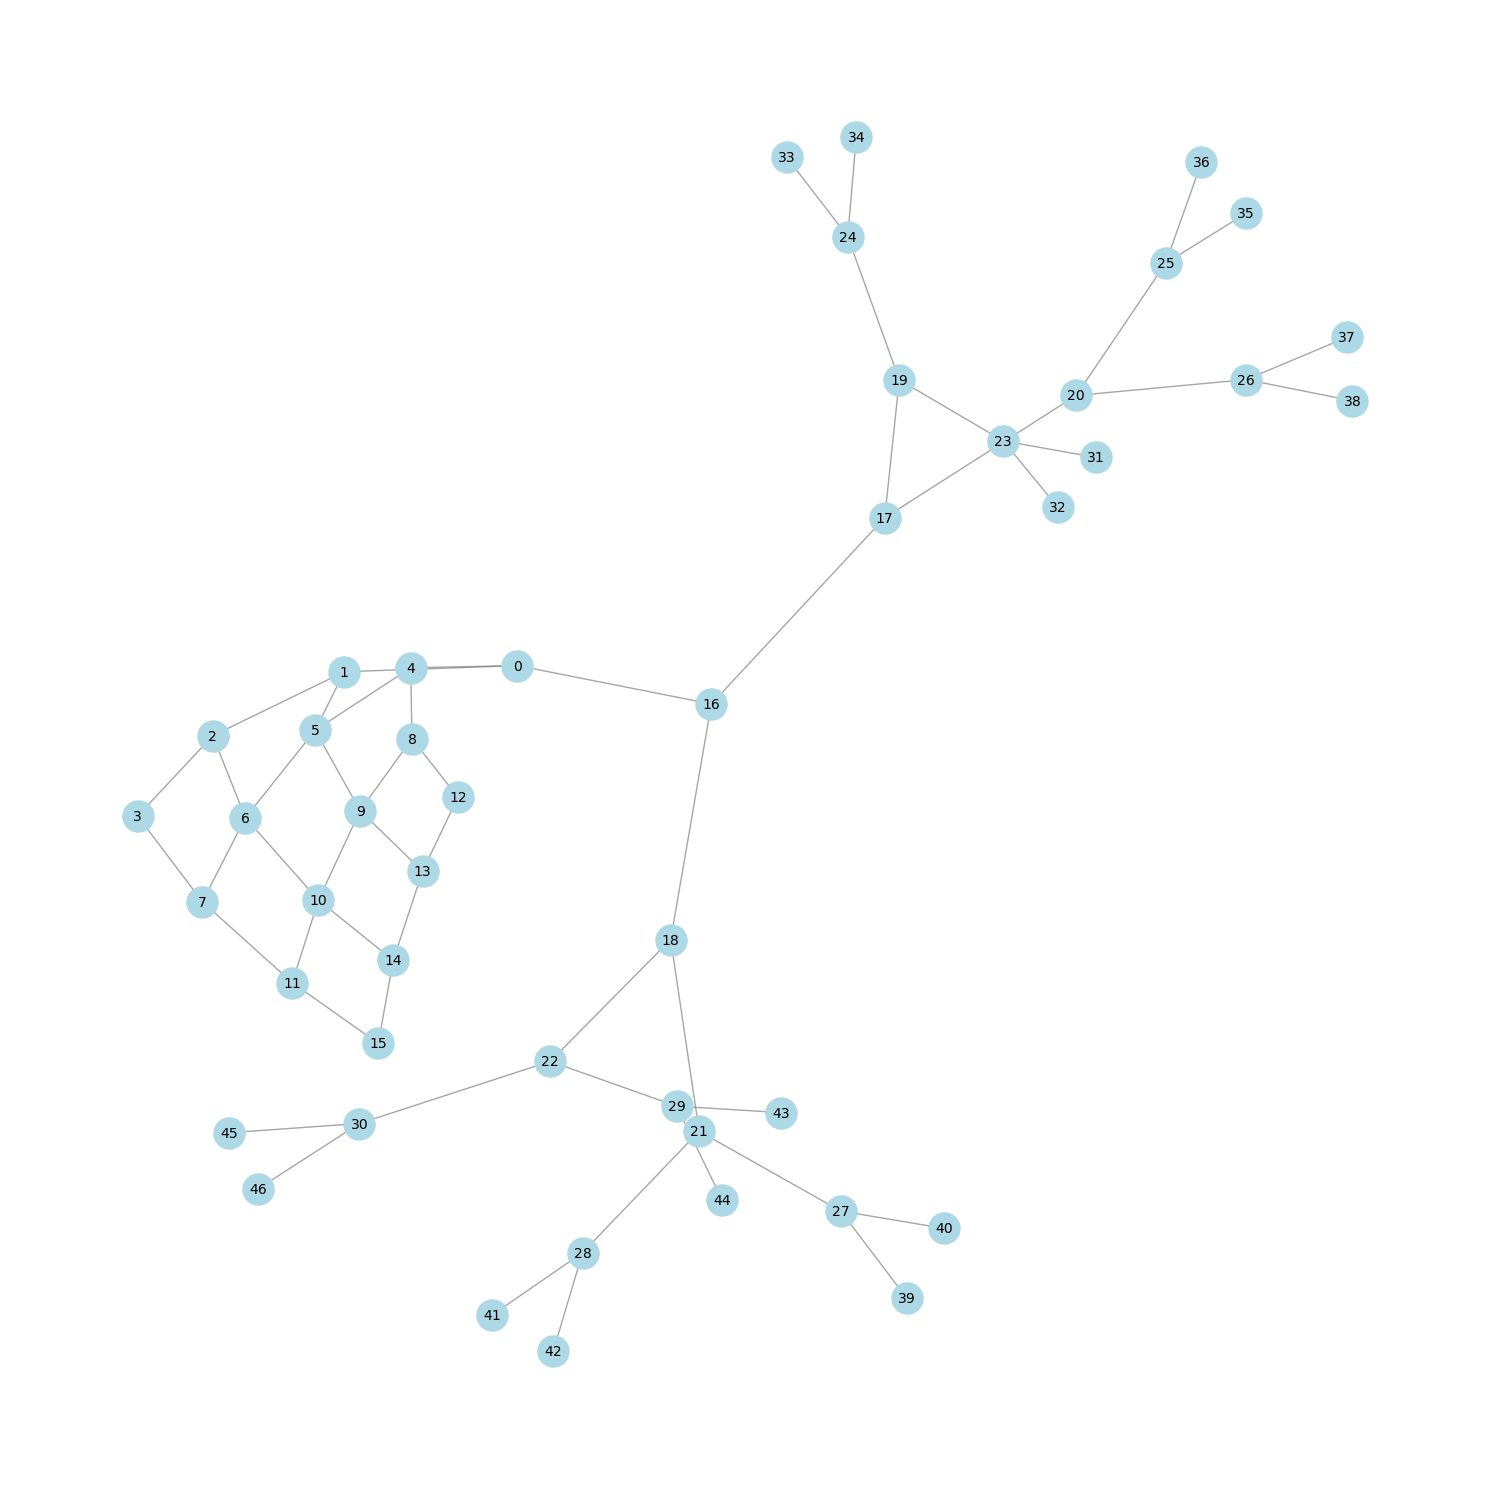

Counter({np.float64(0.0): 171613, np.float64(1.0): 5928, np.float64(2.0): 792, np.float64(3.0): 32})


In [41]:
G = make_tree_with_grid(height_tree=4, leaves_per_node=2, size_grid=4)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(15,15))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

## l2 locality regularization

The localized nodes are: [16] and lambda is 2000000
The only data fidelity component mu times delta is: 0.05178747309977447
La cost function e' 0.05178747309977447 - 0.0011324359431502812: 0.05065503715662419
Too many quadruples to visualize (10), showing only the first 9.


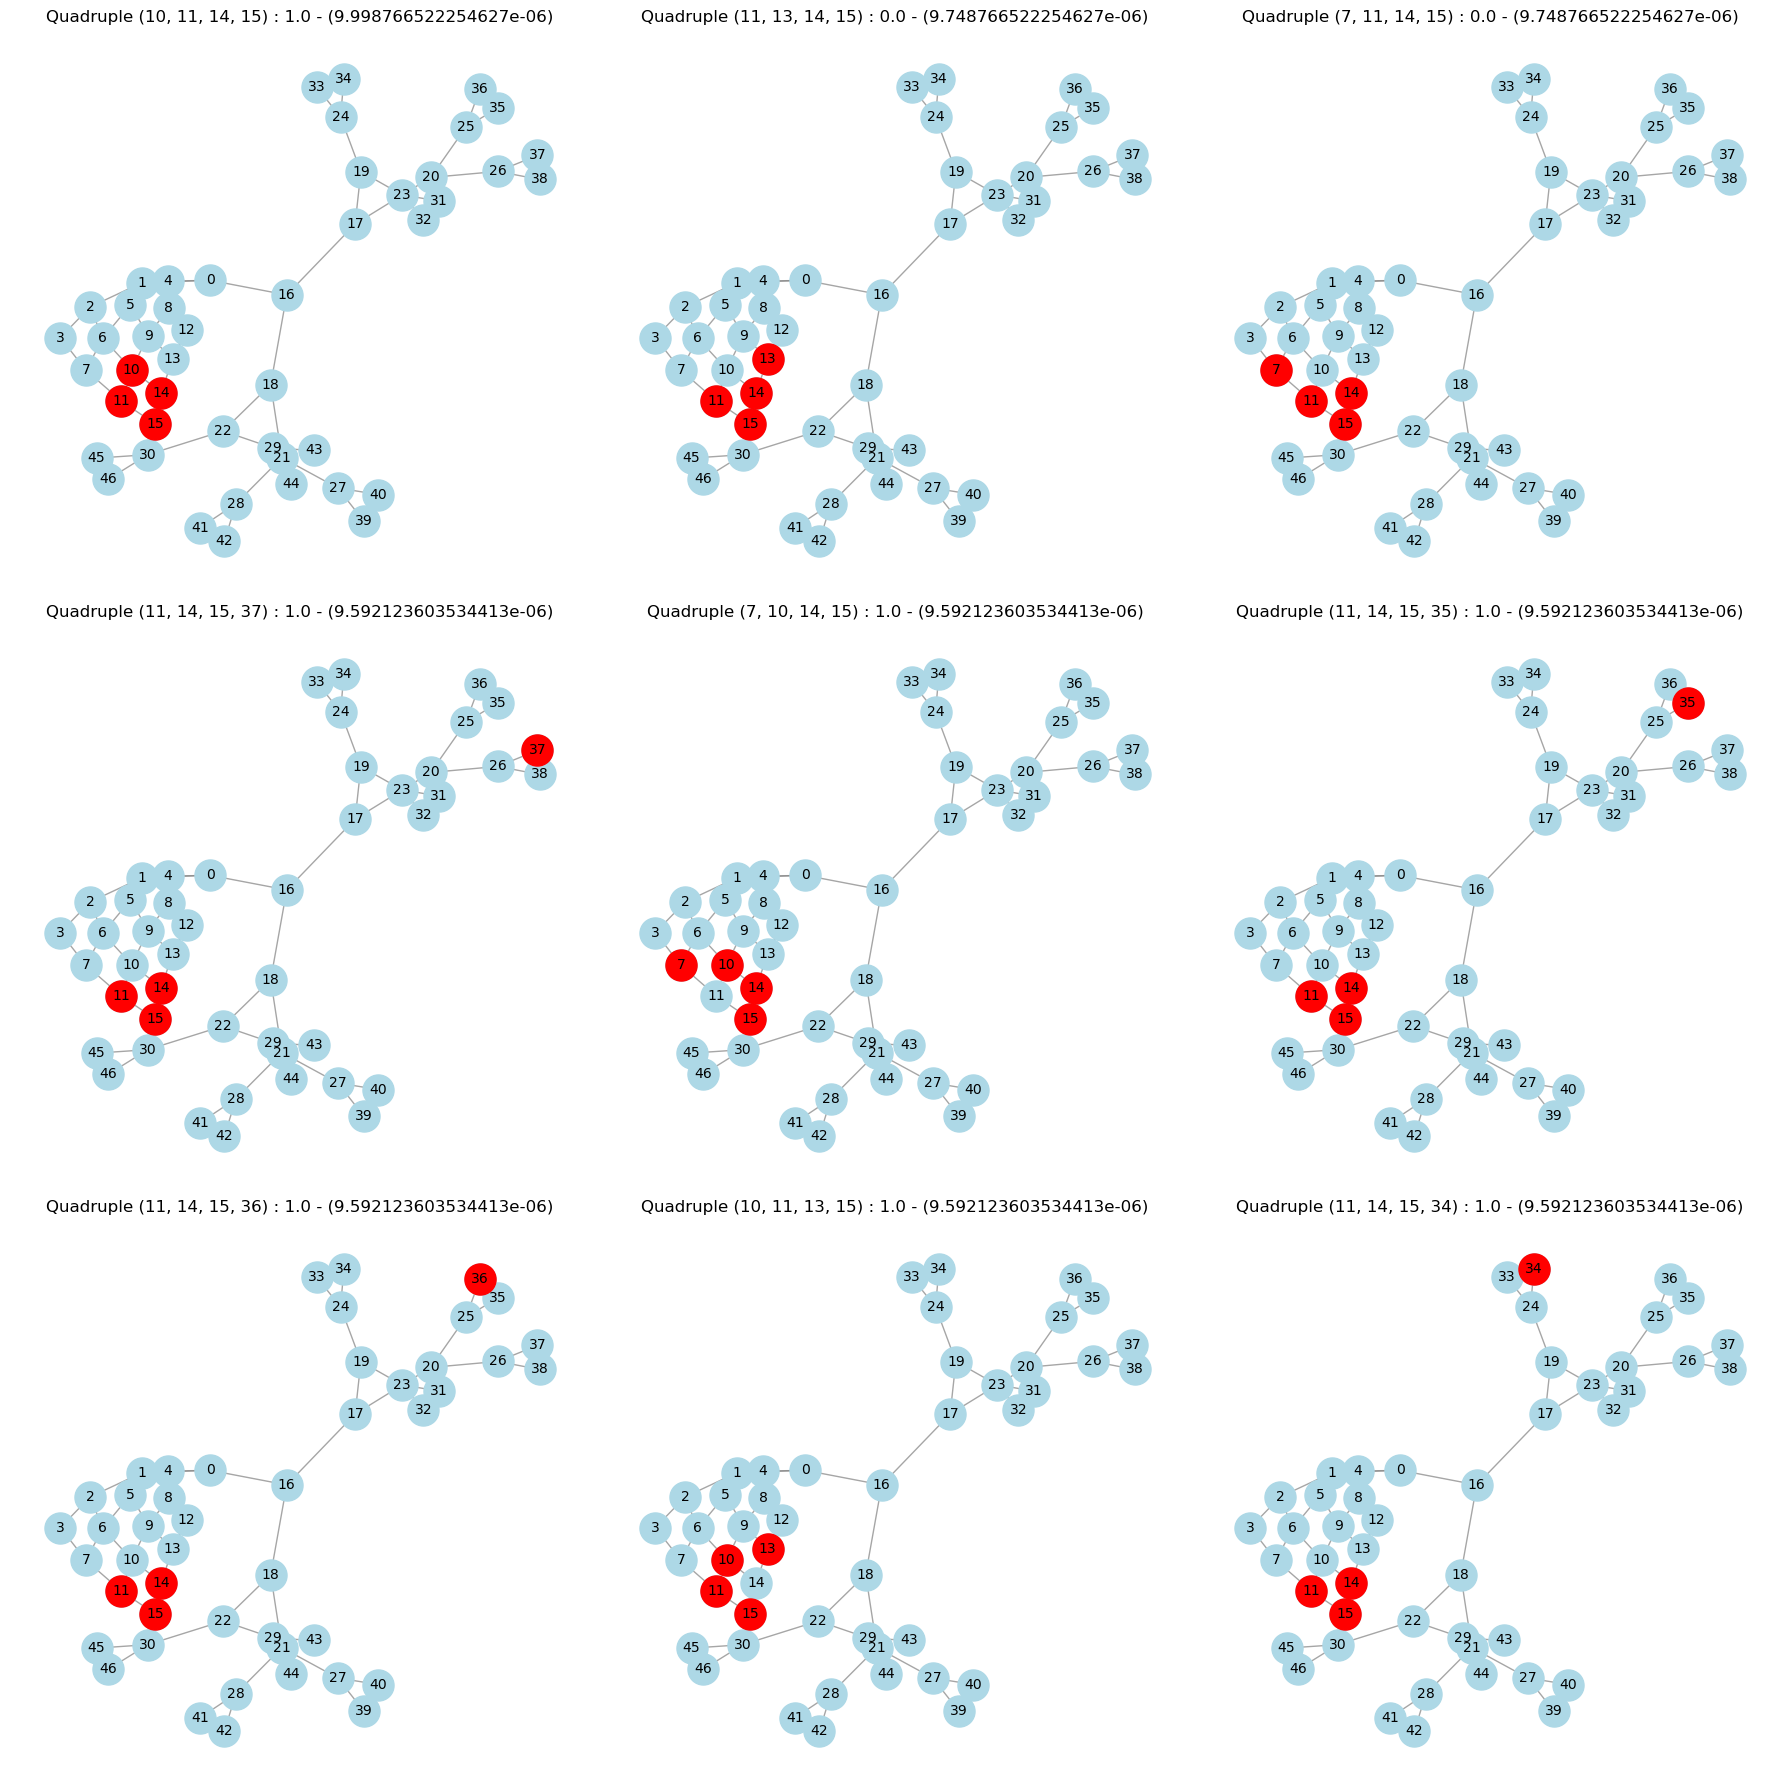

The localized nodes are: [15] and lambda is 2000000
The only data fidelity component mu times delta is: 0.026719261270621207
La cost function e' 0.026719261270621207 - 0.0011324359431502807: 0.025586825327470926
Too many quadruples to visualize (10), showing only the first 9.


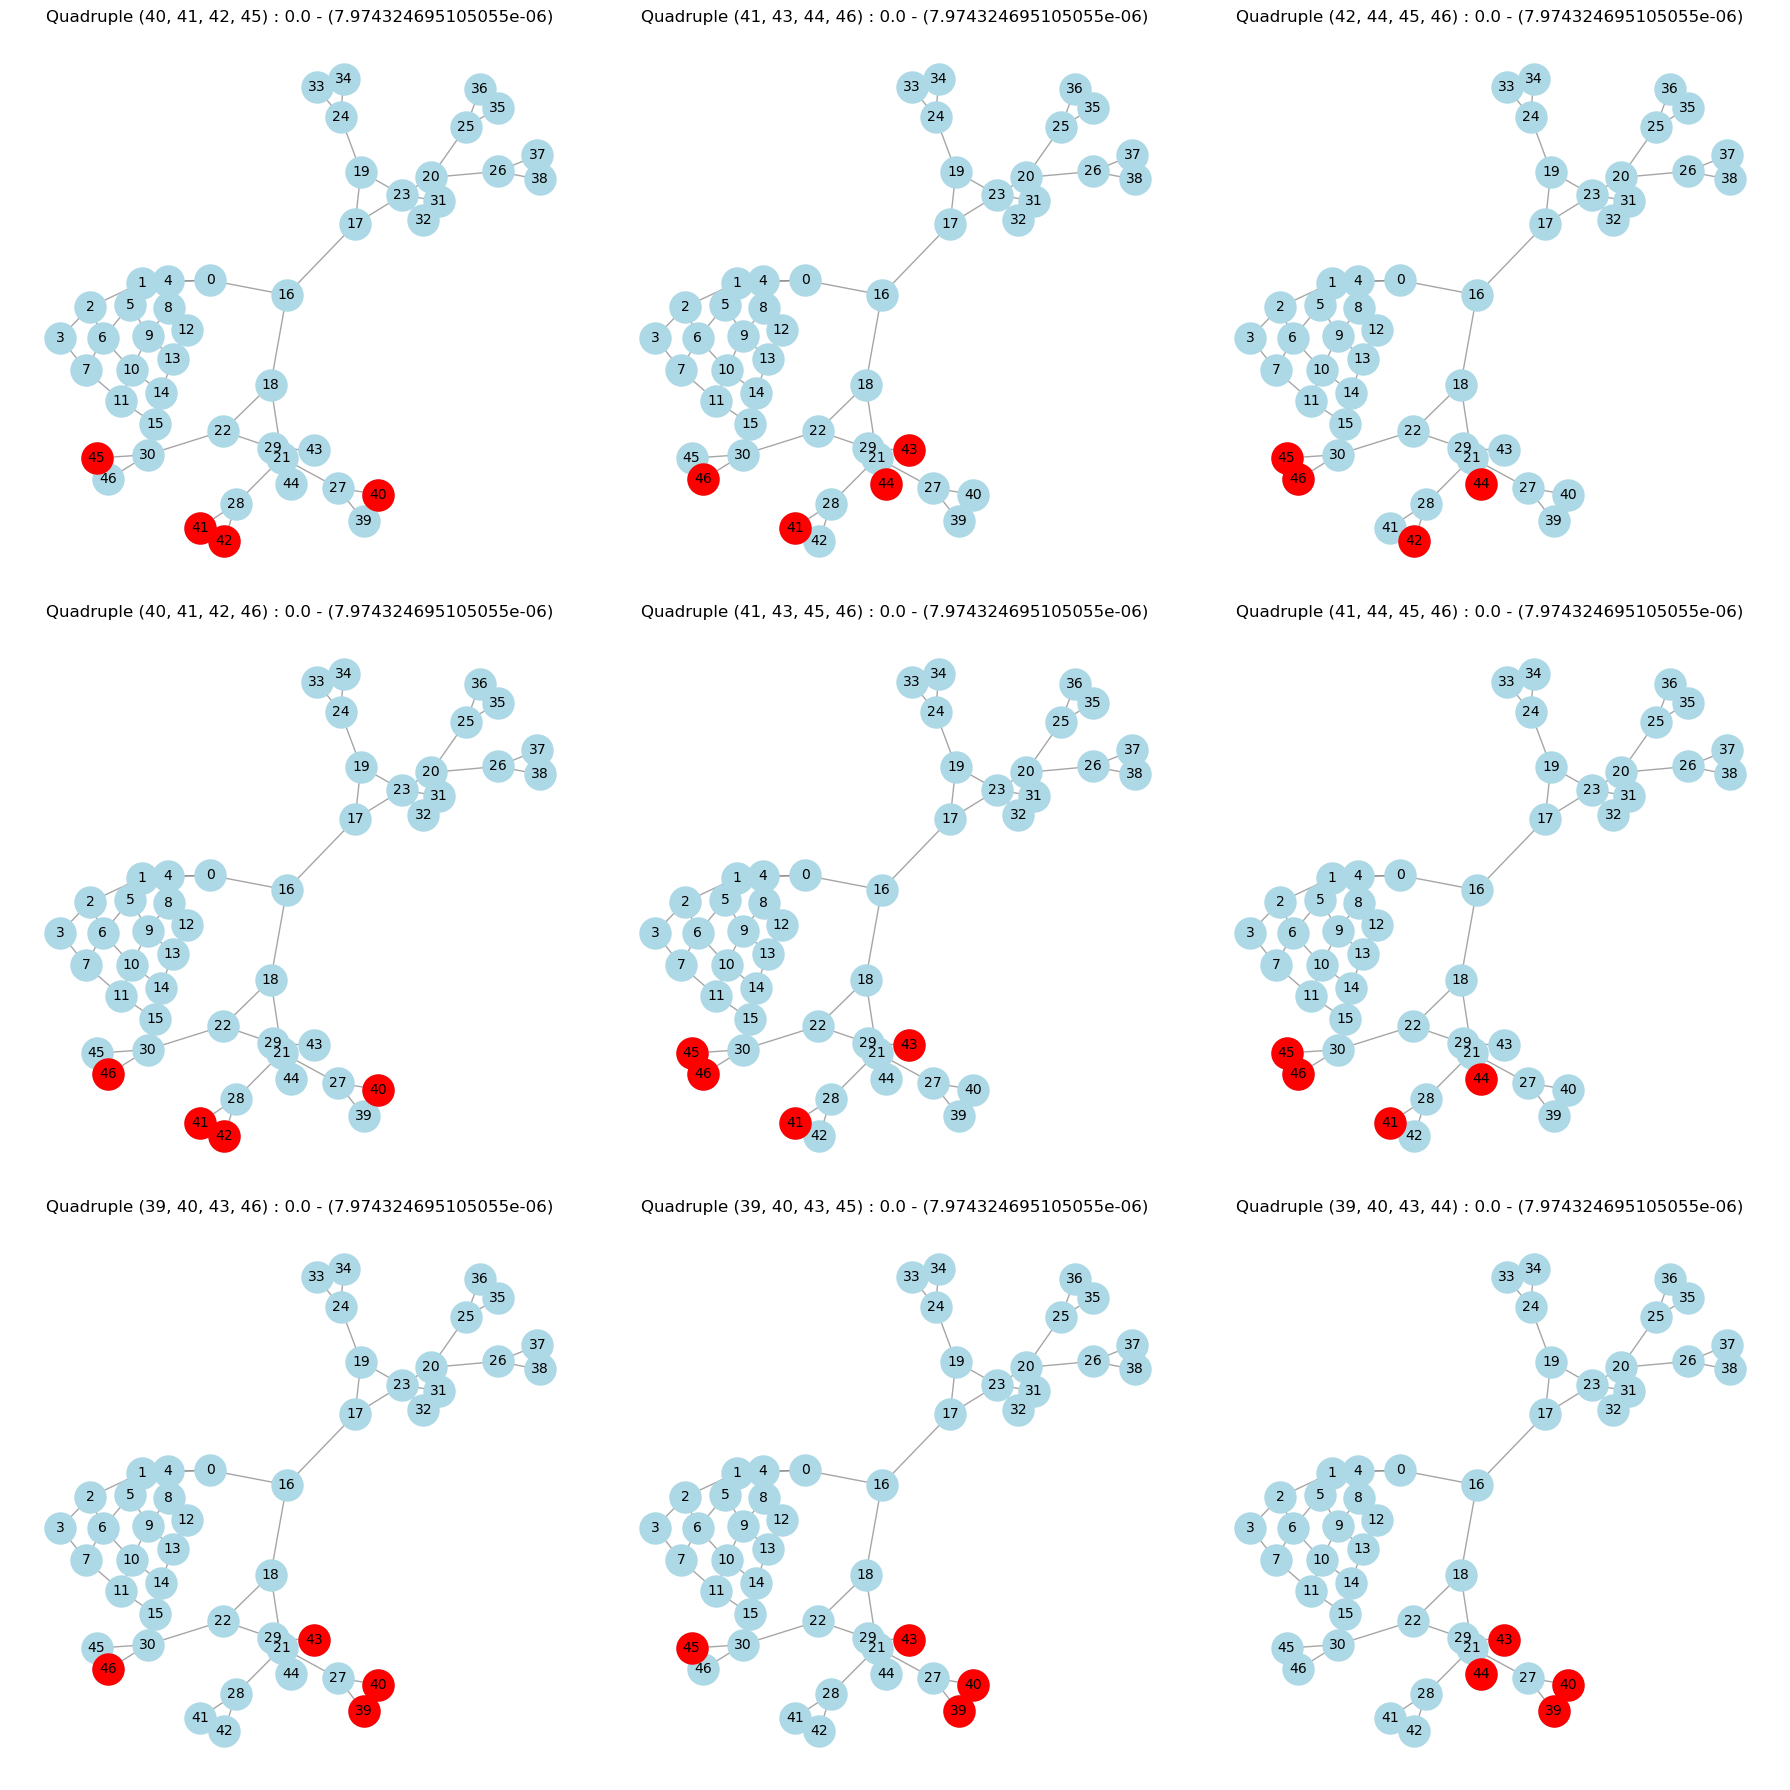

(<Figure size 1800x1800 with 9 Axes>,
 array([<Axes: title={'center': 'Quadruple (40, 41, 42, 45) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (41, 43, 44, 46) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (42, 44, 45, 46) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (40, 41, 42, 46) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (41, 43, 45, 46) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (41, 44, 45, 46) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (39, 40, 43, 46) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (39, 40, 43, 45) : 0.0 - (7.974324695105055e-06)'}>,
        <Axes: title={'center': 'Quadruple (39, 40, 43, 44) : 0.0 - (7.974324695105055e-06)'}>],
       dtype=object))

In [48]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
lambda_reg = 2000000
localized_nodes = [16]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
#E_gromov = normalize(E_gromov)
#W_local = normalize(W_local)
W_local = W_local / np.sum(W_local)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = lambda_reg * (mu - W_local)**2
cost_function_val = np.sum(first_term - second_term)
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
#plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

localized_nodes = [15]
print(f"The localized nodes are: {localized_nodes} and lambda is {lambda_reg}")
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads, localized_nodes, dist_matrix)
#E_gromov = normalize(E_gromov)
#W_local = normalize(W_local)
W_local = W_local / np.sum(W_local)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = lambda_reg * (mu - W_local)**2
cost_function_val = np.sum(first_term - second_term)
print(f"The only data fidelity component mu times delta is: {np.sum(mu * E_gromov)}")
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")
#plot_hist(mu, title="$\\mu$ distribution")

k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu_values = [mu[i] for i in top_indices] 

draw_quadruples(G,pos,top_quads, top_deltas, top_mu_values, max_to_draw=9)

------------

# experiments from the meeting 8 May

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_distance_based(quads,localized_nodes,dist_matrix)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")


In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_alpha(quads,localized_nodes,L_normalized,alpha_diffusion)

results = diffuse_signal_denoising_solve([localized_nodes], L_normalized, alpha_diffusion)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")


In [ ]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]


draw_quadruples(G,pos,top_quads, top_deltas, max_to_draw=9)

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_time(quads,localized_nodes,L_normalized,time)

results = diffuse_signal_heat_kernel([localized_nodes], L_normalized, time)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_time(quads,localized_nodes,L_normalized,time)

results = diffuse_signal_heat_kernel([localized_nodes], L_normalized, time)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_KL_regularization(cost_vector, W_local, temperature)

first_term = mu * cost_vector
second_term = KL_divergence(mu, W_local, temperature)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

-----------

In [ ]:
G = nx.cycle_graph(n=50)
pos = draw_layout(G)
dist_matrix = compute_distance_nodes(G)
L_normalized = nx.normalized_laplacian_matrix(G).toarray()
L = nx.laplacian_matrix(G).toarray()
draw_graphs(G,pos, base_figsize=(5,5))
delta_max, quads = compute_gromov_hyperbolicity(G)
delta_distribution = Counter(quads.values())
print(delta_distribution)
quads = list(itertools.combinations(list(G.nodes()), 4))

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = local_weights_diffuse_based_time(quads,localized_nodes,L_normalized,time)

results = diffuse_signal_heat_kernel([localized_nodes], L_normalized, time)
for x in results:
    draw_graph_with_values(G,pos,x)

cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

In [ ]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]


draw_quadruples(G,pos,top_quads, top_deltas, max_to_draw=9)

In [ ]:
temperature,alpha_diffusion,time,localized_nodes,lambda_reg = get_opt_pm()
E_gromov = gromov_energy(quads, dist_matrix)
W_local = np.zeros(len(quads))
for quad in quads:
    if any(x in quad for x in [16]):
        print(list(quad))
        W_local[list(quad)] = 1
W_local /= np.sum(W_local)


cost_vector = E_gromov 

mu = solve_l2_regularization(cost_vector, W_local, lambda_reg)

first_term = mu * cost_vector
second_term = l2_regularization(mu - W_local, lambda_reg)
cost_function_val = np.sum(first_term - second_term)
print(f"La cost function e' {np.sum(first_term)} - {np.sum(second_term)}: {cost_function_val}")

plot_hist(W_local, title=f"Local weights (Mean={np.mean(W_local):.4f}, Var={np.var(W_local):.4f})", bins=50)
plot_hist(mu, title="$\\mu$ distribution (Entropic Solution)")

In [ ]:
top_mu

In [ ]:
W_local

In [ ]:
k = 10
top_indices = np.argsort(mu)[-k:][::-1]
top_quads = [quads[i] for i in top_indices]
top_deltas = [compute_delta_gromov(dist_matrix,quads[i]) for i in top_indices]
top_mu = [mu[i] for i in top_indices]


draw_quadruples(G,pos,top_quads, top_deltas, max_to_draw=9)